# Preprocesamiento de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import re
from collections import defaultdict
import warnings

In [2]:
df = pd.read_csv("train.csv") # Datos crudos: series de precios de los activos (una columna por activo).
df

,date_id,LME_AH_Close,LME_CA_Close,LME_PB_Close,LME_ZS_Close,JPX_Gold_Mini_Futures_Open,JPX_Gold_Rolling-Spot_Futures_Open,JPX_Gold_Standard_Futures_Open,JPX_Platinum_Mini_Futures_Open,JPX_Platinum_Standard_Futures_Open,...,FX_GBPCAD,FX_CADCHF,FX_NZDCAD,FX_NZDCHF,FX_ZAREUR,FX_NOKGBP,FX_NOKCHF,FX_ZARCHF,FX_NOKJPY,FX_ZARGBP
0,0,2264.5,7205.0,2570.0,3349.0,NaN,NaN,NaN,NaN,NaN,...,1.699987,0.776874,0.888115,0.689954,0.066653,0.090582,0.119630,0.078135,13.822740,0.059163
1,1,2228.0,7147.0,2579.0,3327.0,NaN,NaN,NaN,NaN,NaN,...,1.695279,0.778682,0.889488,0.692628,0.067354,0.091297,0.120520,0.079066,13.888146,0.059895
2,2,2250.0,7188.5,2587.0,3362.0,4684.0,4691.0,4684.0,3363.0,3367.0,...,1.692724,0.780186,0.894004,0.697490,0.067394,0.091478,0.120809,0.079287,13.983675,0.060037
3,3,2202.5,7121.0,2540.0,3354.0,4728.0,4737.0,4729.0,3430.0,3426.0,...,1.683111,0.785329,0.889439,0.698502,0.067639,0.091558,0.121021,0.079285,14.035571,0.059983
4,4,2175.0,7125.0,2604.0,3386.0,NaN,NaN,NaN,NaN,NaN,...,1.684816,0.787264,0.891042,0.701485,0.067443,0.091266,0.121055,0.078925,14.013760,0.059503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1956,1956,2629.5,9778.5,2010.0,2818.5,16041.0,16183.0,16046.0,6076.0,6073.0,...,1.842075,0.584336,0.819066,0.478610,0.048581,0.073181,0.078771,0.045312,14.606239,0.042097
1957,1957,2646.5,9860.0,2014.5,2838.5,NaN,NaN,NaN,NaN,NaN,...,1.844791,0.583610,0.816264,0.476380,0.048547,0.072941,0.078532,0.045315,14.502889,0.042089
1958,1958,2658.5,9919.5,2011.0,2860.0,16132.5,16261.0,16134.0,6200.0,6200.0,...,1.839538,0.583402,0.816093,0.476110,0.048495,0.073421,0.078794,0.045184,14.580416,0.042103
1959,1959,2651.0,9930.5,2032.0,2862.0,16214.5,16341.0,16211.0,6175.0,6195.0,...,1.847106,0.582341,0.822465,0.478955,0.048457,0.072909,0.078424,0.045193,14.492839,0.042015


In [3]:
CATEGORY_MAP = {
    # Energía (oil & gas)
    "COP": ["energy"], "MPC": ["energy"], "DVN": ["energy"],
    "CVX": ["energy"], "CVE": ["energy"], "BP":  ["energy"],
    "BKR": ["energy"], "WMB": ["energy"],

    # Oro / metales preciosos
    "GLD": ["gold"], "NEM": ["gold"],

    # Materiales / metales industriales (proxy sectorial)
    "XLB": ["materials"],

    # Tasas / bonos (drivers macro; útiles para oro/energía)
    "IEF": ["rates"], "BND": ["rates"], "AGG": ["rates"],

    # Crédito
    "JNK": ["credit"], "VCIT": ["credit"], "EMB": ["credit_emerging"],

    # Asia / demanda manufacturera
    "EWJ": ["asia_equity"],

    # Bancos (condiciones financieras; factor macro)
    "MS": ["financials"], "BCS": ["financials"],
}

# === 2) Helper: extraer el ticker desde 'US_Stock_<TICKER>_adj_volume' ===
TICKER_REGEX = re.compile(r"US_Stock_(?P<ticker>[A-Z]+)_adj_close$", re.IGNORECASE)

def extract_ticker(colname: str) -> str | None:
    m = TICKER_REGEX.search(colname)
    if not m: 
        return None
    return m.group("ticker").upper()

# === 3) Función principal de categorización ===
def categorize_columns(columns):
    categories = defaultdict(list)
    unknown = []
    tickers = {}

    for c in columns:
        t = extract_ticker(c)
        tickers[c] = t
        if t is None:
            unknown.append(c)
            continue
        cats = CATEGORY_MAP.get(t)
        if not cats:
            unknown.append(c)
        else:
            for cat in cats:
                categories[cat].append(c)
    categories = {k: sorted(v) for k, v in categories.items()}
    unknown = sorted(unknown)
    return categories, unknown, tickers

def categorize_df(df):
    return categorize_columns(df.columns)

In [4]:
cats, unknown, tickers = categorize_df(df)

print("Categorías detectadas:")
for k, v in cats.items():
    print(f"  - {k}: {len(v)} cols")

if unknown:
    print("\nNo mapeadas (revisa si quieres agregarlas al mapa):")
    for c in unknown:
        print("  ", c)

Categorías detectadas:
  - rates: 3 cols
  - financials: 2 cols
  - energy: 8 cols
  - credit_emerging: 1 cols
  - asia_equity: 1 cols
  - gold: 2 cols
  - credit: 2 cols
  - materials: 1 cols

No mapeadas (revisa si quieres agregarlas al mapa):
   FX_AUDCAD
   FX_AUDCHF
   FX_AUDJPY
   FX_AUDNZD
   FX_AUDUSD
   FX_CADCHF
   FX_CADJPY
   FX_CADUSD
   FX_CHFJPY
   FX_EURAUD
   FX_EURCAD
   FX_EURCHF
   FX_EURGBP
   FX_EURJPY
   FX_EURNZD
   FX_EURUSD
   FX_GBPAUD
   FX_GBPCAD
   FX_GBPCHF
   FX_GBPJPY
   FX_GBPNZD
   FX_GBPUSD
   FX_NOKCHF
   FX_NOKEUR
   FX_NOKGBP
   FX_NOKJPY
   FX_NOKUSD
   FX_NZDCAD
   FX_NZDCHF
   FX_NZDJPY
   FX_NZDUSD
   FX_USDCHF
   FX_USDJPY
   FX_ZARCHF
   FX_ZAREUR
   FX_ZARGBP
   FX_ZARJPY
   FX_ZARUSD
   JPX_Gold_Mini_Futures_Close
   JPX_Gold_Mini_Futures_High
   JPX_Gold_Mini_Futures_Low
   JPX_Gold_Mini_Futures_Open
   JPX_Gold_Mini_Futures_Volume
   JPX_Gold_Mini_Futures_open_interest
   JPX_Gold_Mini_Futures_settlement_price
   JPX_Gold_Rolling-Spot_Fu

In [5]:
warnings.filterwarnings("ignore")

# ---------- 1) Conversión robusta a numérico ----------
def robust_to_numeric(s: pd.Series) -> pd.Series:
    x = s.astype(str).str.strip()
    x = x.str.replace(r"^\((.*)\)$", r"-\1", regex=True)  # (123.4) -> -123.4
    x = x.str.replace("%", "", regex=False)
    x = x.str.replace(",", "", regex=False)
    x = x.replace({"": np.nan, "nan": np.nan, "None": np.nan})
    return pd.to_numeric(x, errors="coerce")

def to_numeric_df(df_in: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df_in.index)
    for c in df_in.columns:
        out[c] = robust_to_numeric(df_in[c])
    return out

df_num = to_numeric_df(df)   # <<< trabajaremos siempre en numérico

# ---------- 2) Diagnóstico (opcional) ----------
def debug_category(df_num: pd.DataFrame, cols: list[str]):
    rows = []
    for c in cols:
        if c not in df_num.columns:
            rows.append((c, "NO_COL", 0.0, 0.0))
            continue
        s = df_num[c]
        nnr = s.notna().mean()
        stdv = float(s.std(ddof=1)) if nnr > 0 else 0.0
        status = "OK" if stdv > 0 else "CONST_OR_NAN"
        rows.append((c, status, nnr, stdv))
    return pd.DataFrame(rows, columns=["col","status","non_na_ratio","std"]).sort_values(
        ["status","non_na_ratio","std"], ascending=[True, False, False]
    )

# Ejemplo de diagnóstico para ENERGY:
# display(debug_category(df_num, cats.get("energy", [])))

# ---------- 3) Selector con cascada de fallback (SIN PCA) ----------
def pick_rep_fallback(df_num: pd.DataFrame, cols: list[str], min_non_na_ratio: float = 0.05):
    cols = [c for c in cols if c in df_num.columns]
    if not cols:
        return None, {"reason": "no cols in df"}

    metrics = []
    for c in cols:
        s = df_num[c]
        nnr = s.notna().mean()
        stdv = float(s.std(ddof=1)) if nnr > 0 else 0.0
        metrics.append((c, nnr, stdv))
    met = pd.DataFrame(metrics, columns=["col","non_na_ratio","std"])

    # 1) suficiente cobertura + std>0
    cand = met[(met["non_na_ratio"] >= min_non_na_ratio) & (met["std"] > 0)]
    if not cand.empty:
        best = cand.sort_values(["std","non_na_ratio"], ascending=False).iloc[0]["col"]
        return best, {"criterion": "std_with_coverage", "table": met}

    # 2) mayor std aunque cobertura sea baja
    cand2 = met[met["std"] > 0]
    if not cand2.empty:
        best = cand2.sort_values(["std","non_na_ratio"], ascending=False).iloc[0]["col"]
        return best, {"criterion": "std_any_coverage", "table": met}

    # 3) mayor cobertura (aunque std==0)
    cand3 = met.sort_values(["non_na_ratio"], ascending=False)
    if not cand3.empty and cand3.iloc[0]["non_na_ratio"] > 0:
        best = cand3.iloc[0]["col"]
        return best, {"criterion": "max_non_na_ratio", "table": met}

    # 4) último recurso: primera columna
    return cols[0], {"criterion": "first_col_fallback", "table": met}

def pick_representatives_no_pca_robust(df_num: pd.DataFrame, categories: dict[str, list[str]],
                                       min_non_na_ratio: float = 0.05):
    rep_map, details = {}, {}
    for cat, cols in categories.items():
        best, info = pick_rep_fallback(df_num, cols, min_non_na_ratio=min_non_na_ratio)
        rep_map[cat] = best
        details[cat] = info
    # DataFrame reducido: 1 columna por categoría (renombrada con el nombre de la categoría)
    rep_cols = {cat: col for cat, col in rep_map.items() if col is not None}
    rep_df = pd.DataFrame({cat: df_num[col] for cat, col in rep_cols.items()})
    return rep_map, rep_df, details

# ---------- 4) Ejecutar sobre tus categorías detectadas ----------
cats, unknown, tickers = categorize_df(df)   # (si ya tienes cats, puedes omitir esta línea)
rep_map, df, details = pick_representatives_no_pca_robust(df_num, cats, min_non_na_ratio=0.05)

print("Representantes por categoría (SIN PCA):")
for k, v in rep_map.items():
    print(f"{k:>15} -> {v}")

Representantes por categoría (SIN PCA):
          rates -> US_Stock_IEF_adj_close
     financials -> US_Stock_MS_adj_close
         energy -> US_Stock_MPC_adj_close
credit_emerging -> US_Stock_EMB_adj_close
    asia_equity -> US_Stock_EWJ_adj_close
           gold -> US_Stock_GLD_adj_close
         credit -> US_Stock_JNK_adj_close
      materials -> US_Stock_XLB_adj_close


In [6]:
cols = ['rates','financials','energy','credit_emerging','asia_equity','gold','credit','materials']

# 1) Drop de nulos
n0 = len(df)
df = df.dropna()
n1 = len(df)
perdido = n0 - n1
porc_perdido = round(perdido / n0 * 100, 2)

print(f"Filas antes: {n0} | después: {n1} | perdidas: {perdido} ({porc_perdido}%)")

Filas antes: 1961 | después: 1894 | perdidas: 67 (3.42%)


In [7]:
df

,rates,financials,energy,credit_emerging,asia_equity,gold,credit,materials
0,89.761300,41.6019,52.8379,82.036500,53.248900,125.15,69.775800,53.011300
1,89.855100,41.7135,53.9627,82.001300,53.982000,124.82,70.117400,53.382600
2,89.812400,42.3512,54.0177,82.212700,54.644400,125.46,70.212300,53.848900
3,89.701500,42.3352,54.5368,82.262000,54.794500,125.33,70.288300,54.280700
4,89.658900,42.1599,54.5761,82.114000,55.112500,125.31,70.212300,54.358400
...,...,...,...,...,...,...,...,...
1956,95.011400,140.8300,174.2100,92.683171,72.391468,308.39,97.785611,90.679470
1957,95.343538,140.4700,174.8800,93.036192,73.197946,313.13,97.917071,91.141812
1958,95.615286,140.0400,175.2500,93.197573,73.570942,316.10,98.099092,92.398178
1959,95.273084,142.2100,177.5400,93.237919,77.109363,312.18,98.169877,92.709757


# Análisis Exploratorio de Datos


=== Descriptivos numéricos ===


,count,mean,std,min,25%,50%,75%,max
rates,1894.0,95.768082,7.215438,84.0796,89.878600,93.62150,102.392050,110.523500
financials,1894.0,69.603923,28.725690,23.4703,41.451575,74.46920,87.434375,144.140000
energy,1894.0,86.689863,48.397947,14.0711,49.788400,63.26515,133.540200,213.358200
credit_emerging,1894.0,83.702864,6.397175,67.3793,77.689600,83.82520,89.537600,94.603000
asia_equity,1894.0,57.792425,7.546348,39.5872,51.757300,55.76100,64.123050,77.169849
gold,1894.0,174.029340,44.844242,111.1000,141.782500,169.36000,184.000000,316.290000
credit,1894.0,81.175747,7.594640,62.6800,76.374650,80.41790,86.800425,98.169877
materials,1894.0,68.965540,15.405023,34.7139,52.018575,74.26740,80.974425,96.662600



=== Perfil por variable ===


,dtype,unicos,min,q1,mediana,q3,max,media,std
rates,float64,1794,84.0796,89.8786,93.6215,102.39205,110.5235,95.768082,7.215438
financials,float64,1823,23.4703,41.451575,74.4692,87.434375,144.14,69.603923,28.72569
energy,float64,1863,14.0711,49.7884,63.26515,133.5402,213.3582,86.689863,48.397947
credit_emerging,float64,1796,67.3793,77.6896,83.8252,89.5376,94.603,83.702864,6.397175
asia_equity,float64,1708,39.5872,51.7573,55.761,64.12305,77.169849,57.792425,7.546348
gold,float64,1701,111.1,141.7825,169.36,184.0,316.29,174.02934,44.844242
credit,float64,1734,62.68,76.37465,80.4179,86.800425,98.169877,81.175747,7.59464
materials,float64,1816,34.7139,52.018575,74.2674,80.974425,96.6626,68.96554,15.405023


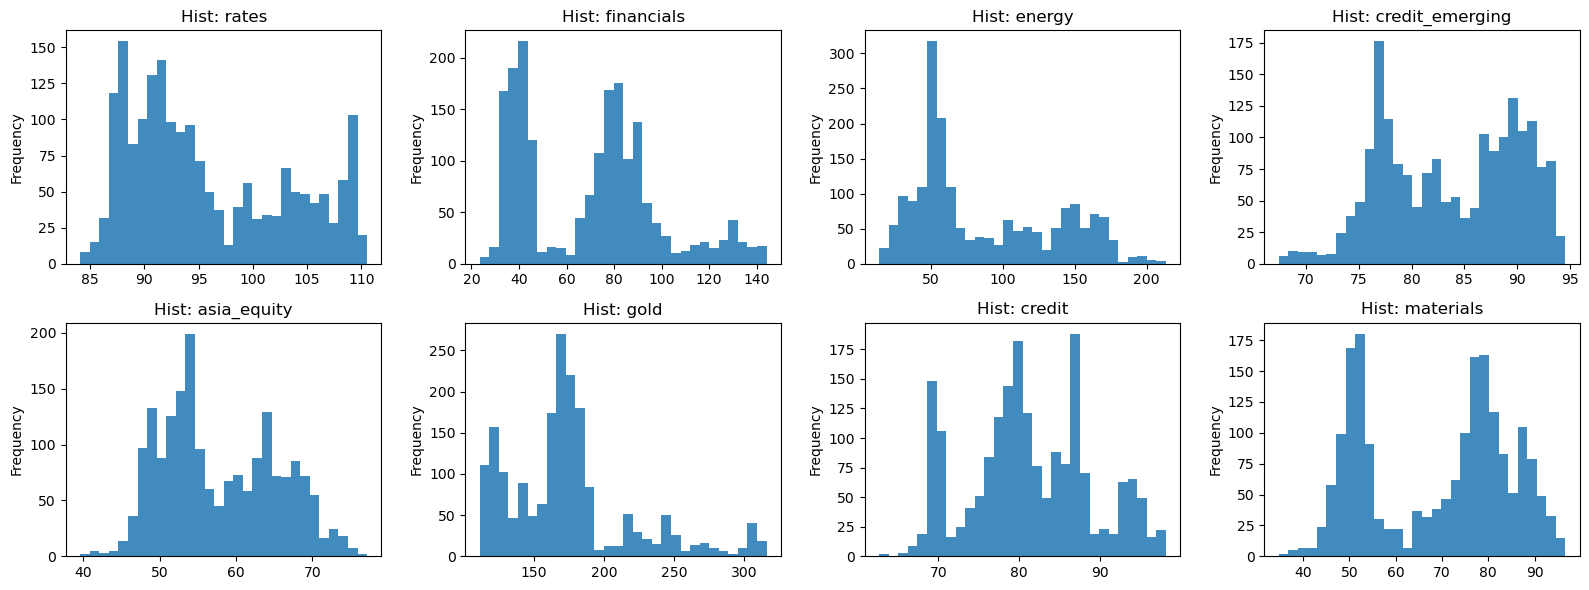

<Figure size 960x500 with 0 Axes>

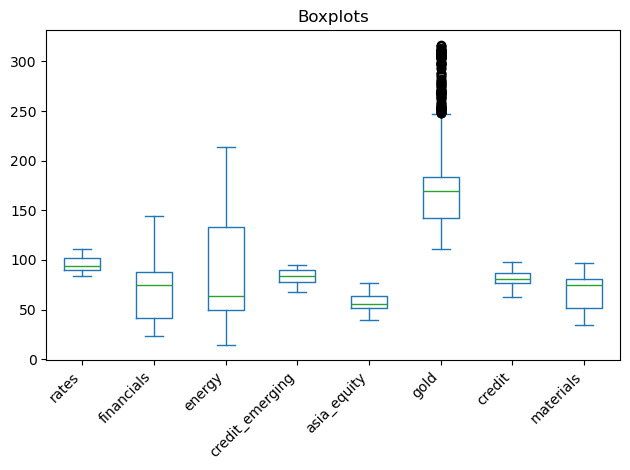

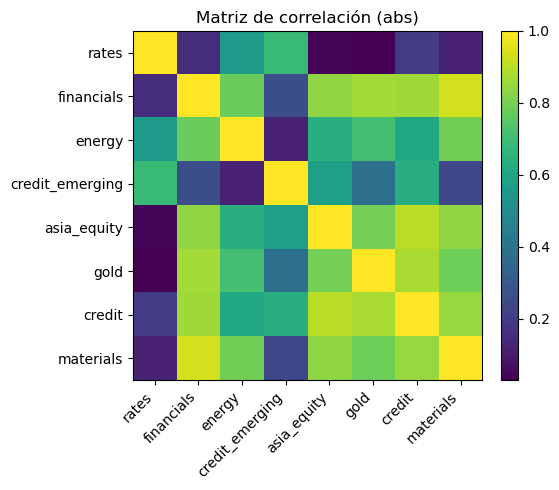


=== Top pares correlacionados (abs) ===


,var_1,var_2,|corr|
0,financials,materials,0.9320
1,asia_equity,credit,0.9001
2,gold,credit,0.8758
3,financials,gold,0.8667
4,financials,credit,0.8617
5,credit,materials,0.8492
6,financials,asia_equity,0.8378
7,asia_equity,materials,0.8372
8,asia_equity,gold,0.7968
9,energy,materials,0.7892


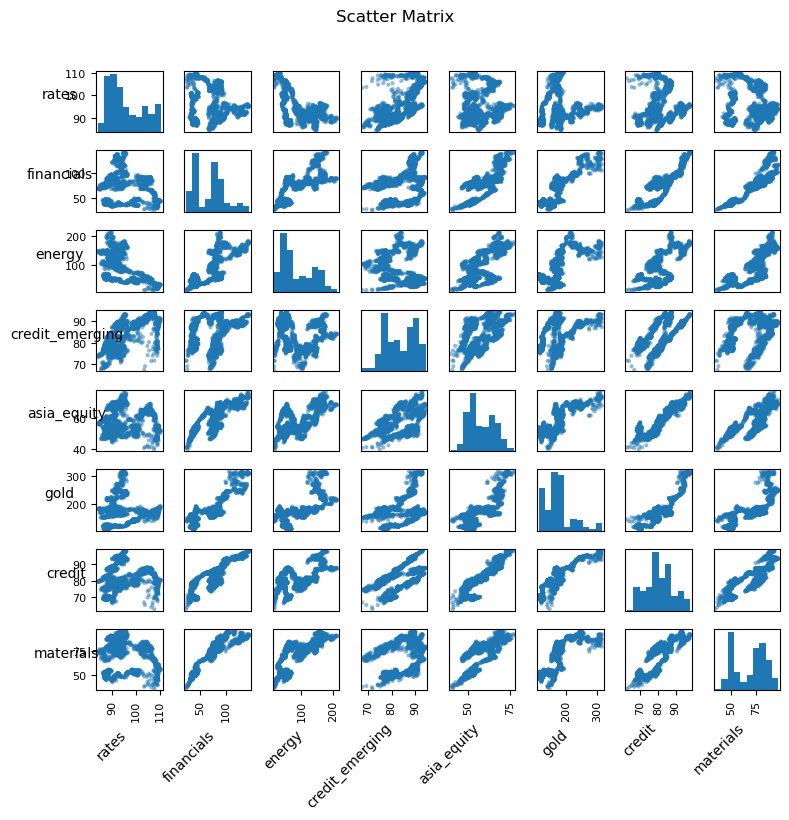

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# 0) Columnas de interés (df ya viene sin nulos)
cols = ['rates','financials','energy','credit_emerging','asia_equity','gold','credit','materials']

# 1) Descriptivos numéricos
desc_num = df.describe().T
print("\n=== Descriptivos numéricos ===")
try: display(desc_num)
except NameError: print(desc_num)

# 2) Perfil por variable (simple)
def perfil_columna(s: pd.Series) -> dict:
    return {
        "dtype": str(s.dtype),
        "unicos": int(s.nunique()),
        "min": s.min(),
        "q1": s.quantile(0.25),
        "mediana": s.median(),
        "q3": s.quantile(0.75),
        "max": s.max(),
        "media": s.mean(),
        "std": s.std()
    }

perfil_tabla = pd.DataFrame({c: perfil_columna(df[c]) for c in df.columns}).T
print("\n=== Perfil por variable ===")
try: display(perfil_tabla)
except NameError: print(perfil_tabla)

# 3) Histogramas
num_cols = df.columns.tolist()
n = len(num_cols)
rows = int(np.ceil(n/4)); cols_grid = min(4, n)
fig, axes = plt.subplots(rows, cols_grid, figsize=(4*cols_grid, 3*rows))
axes = np.array(axes).reshape(-1) if n > 1 else np.array([axes])
for ax, col in zip(axes, num_cols):
    df[col].plot(kind='hist', bins=30, alpha=0.85, ax=ax)
    ax.set_title(f'Hist: {col}')
    ax.set_xlabel('')
for ax in axes[n:]: ax.axis('off')
plt.tight_layout(); plt.show()

# 4) Boxplots
plt.figure(figsize=(max(8, 1.2*len(num_cols)), 5))
df[num_cols].plot(kind='box')
plt.title('Boxplots')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

# 5) Matriz de correlación (abs) + top pares
if len(num_cols) >= 2:
    corr = df.corr(numeric_only=True).abs()
    plt.figure(figsize=(6, 5))
    im = plt.imshow(corr, interpolation='nearest')
    plt.title('Matriz de correlación (abs)')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right')
    plt.yticks(range(len(num_cols)), num_cols)
    plt.tight_layout(); plt.show()

    pares = []
    cols_c = corr.columns
    for i in range(len(cols_c)):
        for j in range(i+1, len(cols_c)):
            pares.append((cols_c[i], cols_c[j], round(corr.iloc[i, j], 4)))
    top_pares = pd.DataFrame(sorted(pares, key=lambda x: x[2], reverse=True)[:10],
                             columns=["var_1", "var_2", "|corr|"])
    print("\n=== Top pares correlacionados (abs) ===")
    try: display(top_pares)
    except NameError: print(top_pares)

# 6) Scatter matrix (muestra opcional si es grande)
sample = df  # o df.sample(1000, random_state=0)
if sample.shape[1] >= 2:
    axarr = scatter_matrix(sample, figsize=(8, 8), diagonal='hist')
    for ax in axarr[-1, :]: ax.set_xlabel(ax.get_xlabel(), rotation=45, ha='right')
    for ax in axarr[:, 0]: ax.set_ylabel(ax.get_ylabel(), rotation=0)
    plt.suptitle('Scatter Matrix', y=1.02)
    plt.tight_layout(); plt.show()

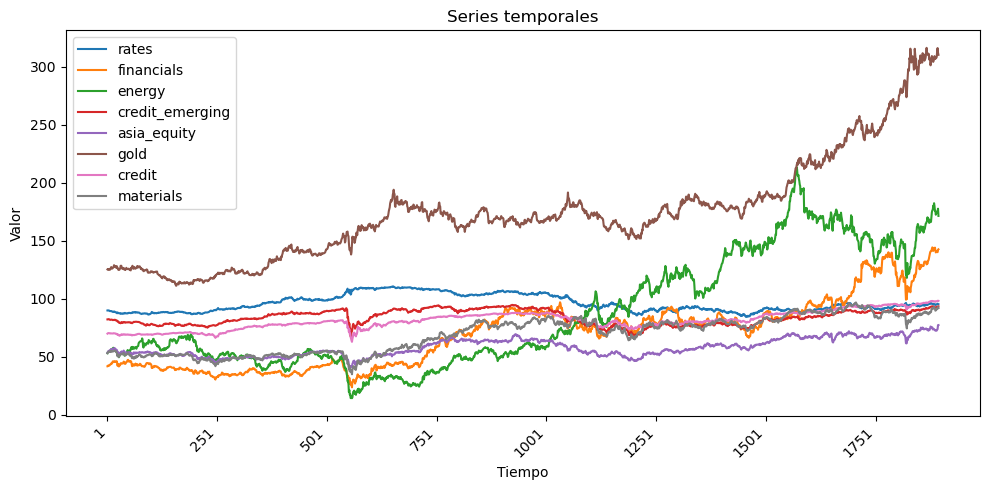

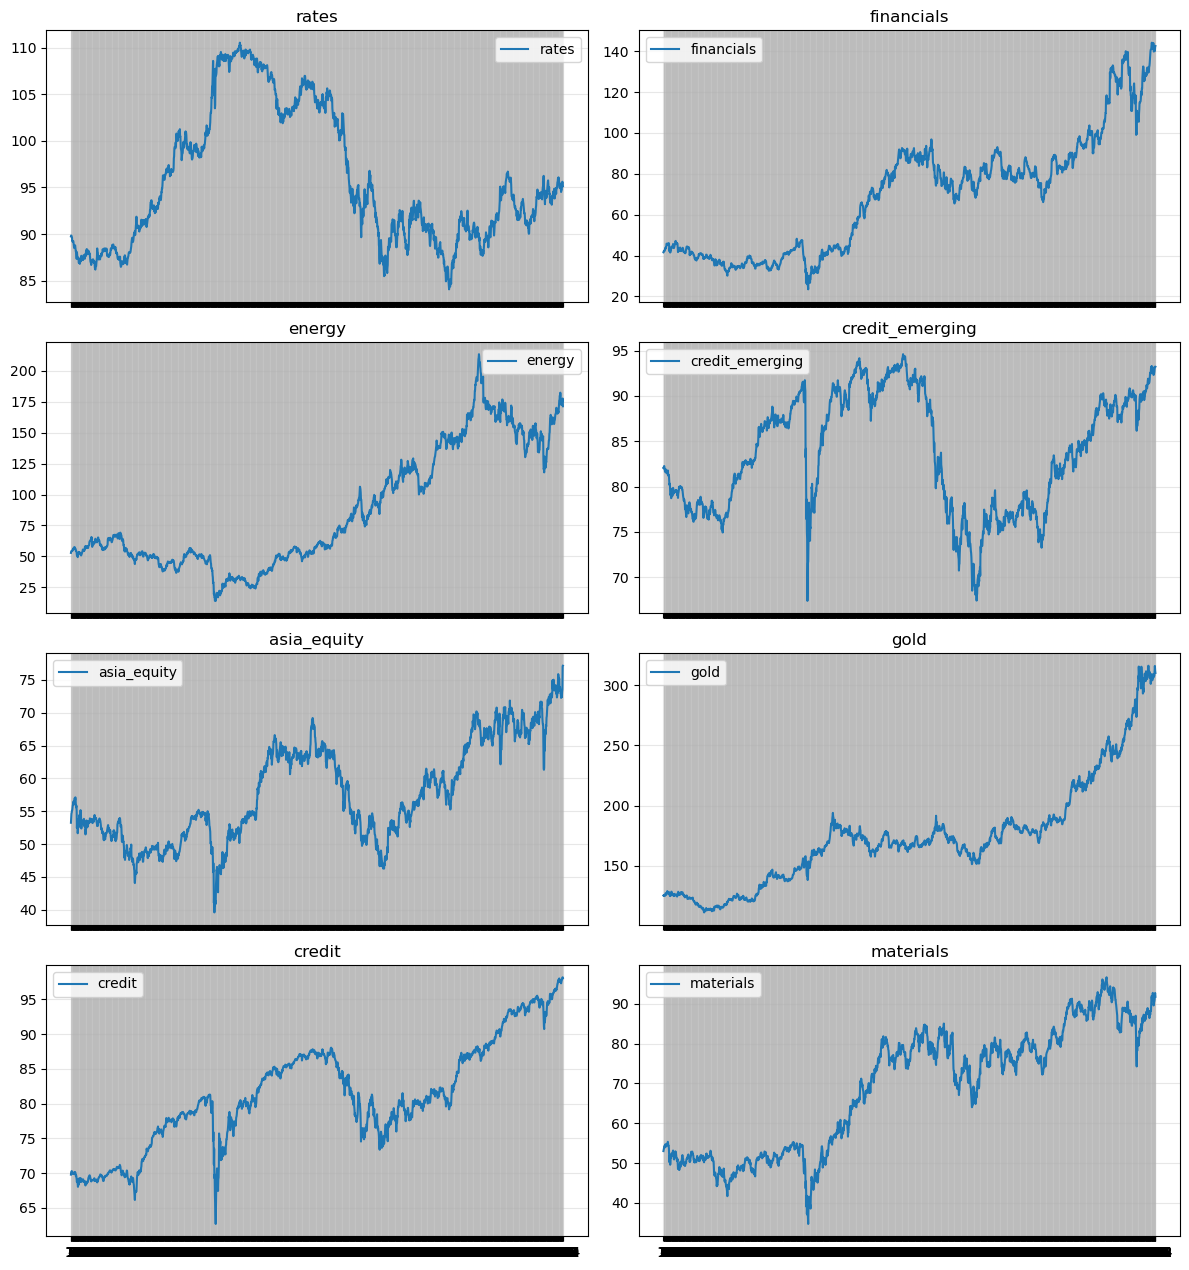

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 0) Tus columnas ---
cols = ['rates','financials','energy','credit_emerging','asia_equity','gold','credit','materials']

# --- 1) Crear índice tipo "Tiempo 1, Tiempo 2, ..." ---
df = df.copy()
df.index = [f"{i+1}" for i in range(len(df))]

# --- 2) Gráfico combinado (todas las series) ---
plt.figure(figsize=(10,5))
df.plot(ax=plt.gca())
plt.title("Series temporales")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 3) Subplots individuales ---
cols = df.columns.tolist()
n = len(cols)
rows = int(np.ceil(n/2))
cols_grid = 2

fig, axes = plt.subplots(rows, cols_grid, figsize=(12, 3.2*rows), sharex=True)
axes = np.array(axes).reshape(-1) if n > 1 else np.array([axes])

for ax, col in zip(axes, cols):
    ax.plot(df.index, df[col], label=col)
    ax.set_title(col)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


# Modelaje - GRU univariante por columna


Entrenando/validando GRU para: rates
{'best_val_mse': 1.675638931736358e-05, 'rmse_val': 0.004093457013733057, 'mae_val': 0.0032820357009768486, 'n_train_samples': 1484, 'n_valid_samples': 349}

Entrenando/validando GRU para: financials
{'best_val_mse': 0.0003855254847473294, 'rmse_val': 0.01963480305110795, 'mae_val': 0.012767256237566471, 'n_train_samples': 1484, 'n_valid_samples': 349}

Entrenando/validando GRU para: energy
{'best_val_mse': 0.000465585736891076, 'rmse_val': 0.021577436429467335, 'mae_val': 0.014728887937963009, 'n_train_samples': 1484, 'n_valid_samples': 349}

Entrenando/validando GRU para: credit_emerging
{'best_val_mse': 2.1619227328251835e-05, 'rmse_val': 0.004649647907424448, 'mae_val': 0.003423442132771015, 'n_train_samples': 1484, 'n_valid_samples': 349}

Entrenando/validando GRU para: asia_equity
{'best_val_mse': 0.00016179496198418926, 'rmse_val': 0.012719865357049935, 'mae_val': 0.009165831841528416, 'n_train_samples': 1484, 'n_valid_samples': 349}

Entren

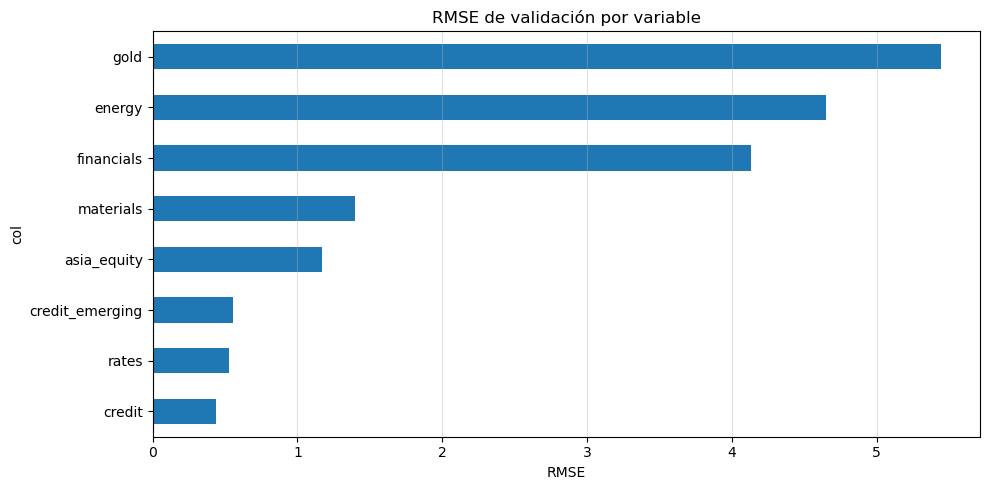

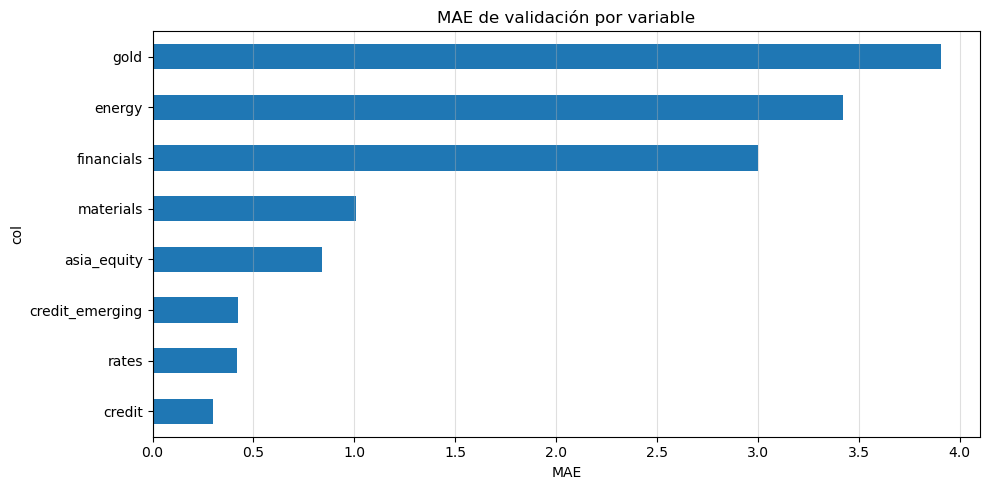

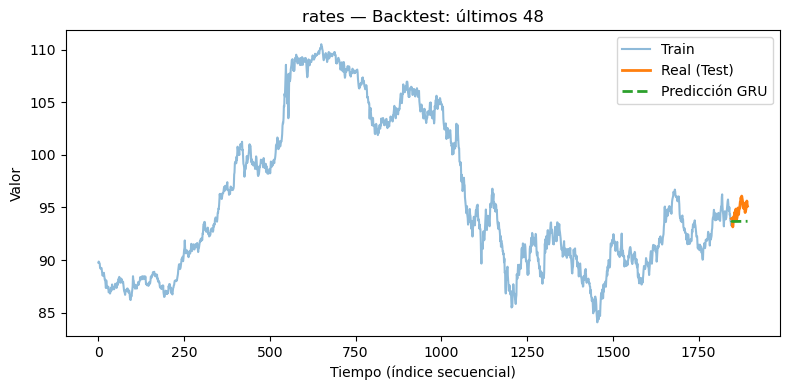

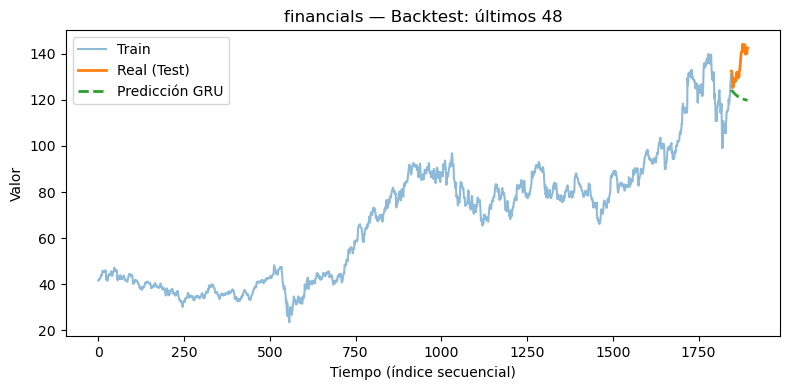

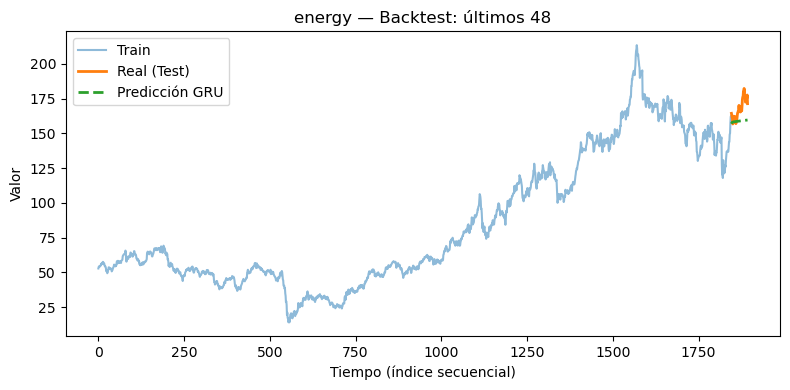

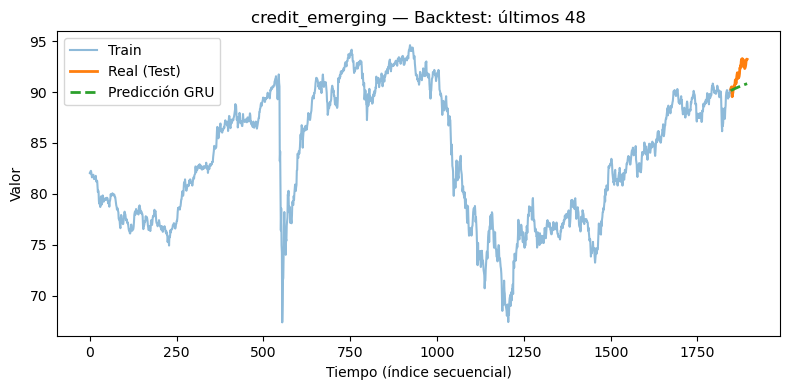

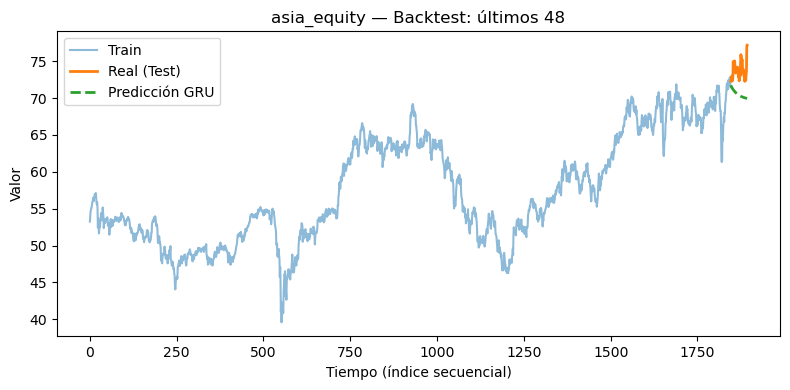

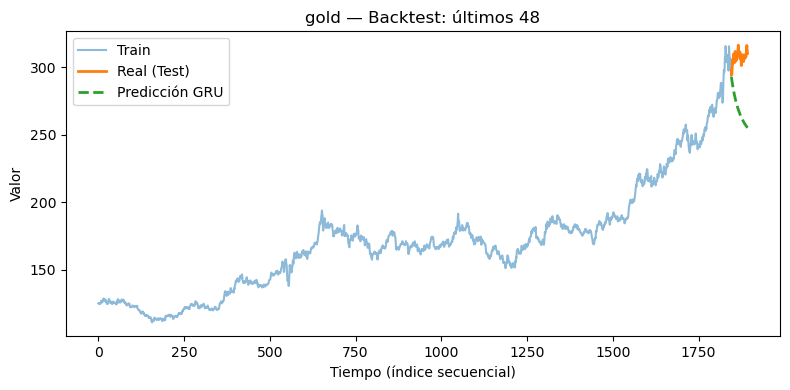

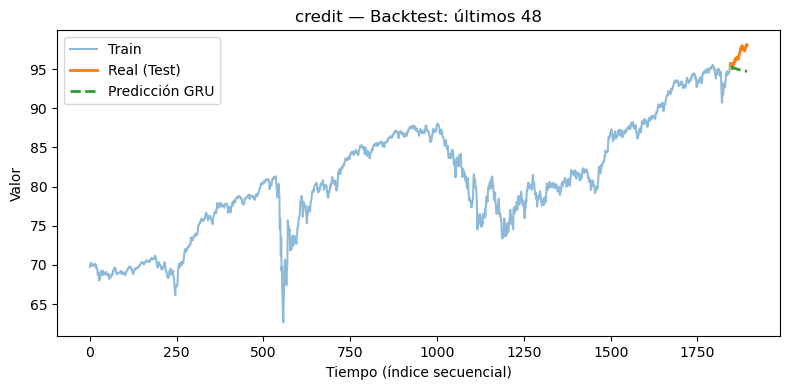

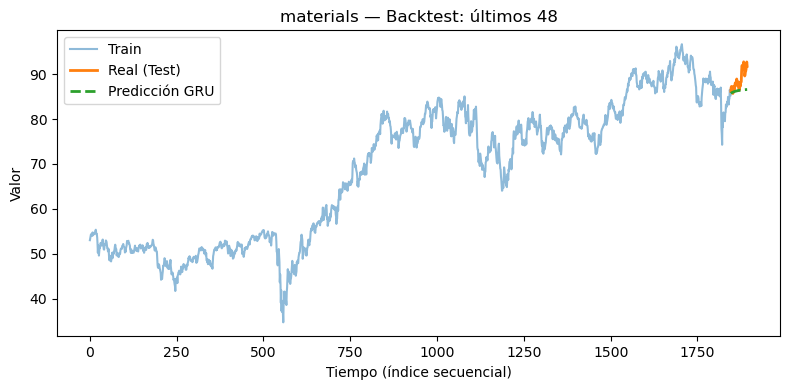


===== Backtest H pasos (menor RMSE mejor) =====
                    rmse_H      mae_H
col                                  
rates             1.274575   1.097516
credit_emerging   1.547046   1.307088
credit            2.128165   1.846830
materials         3.154483   2.477264
asia_equity       3.489435   3.202726
energy           11.013765   8.908444
financials       15.479286  13.758237
gold             40.913530  38.656766


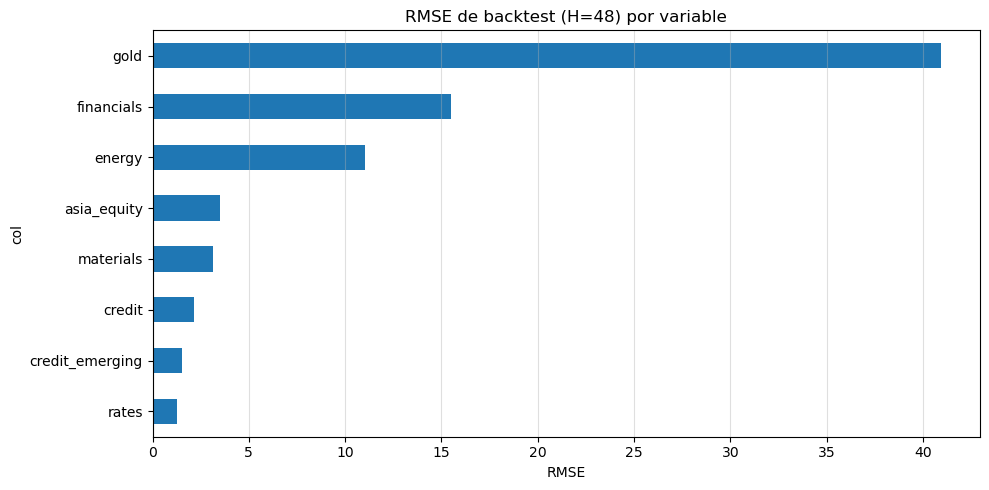

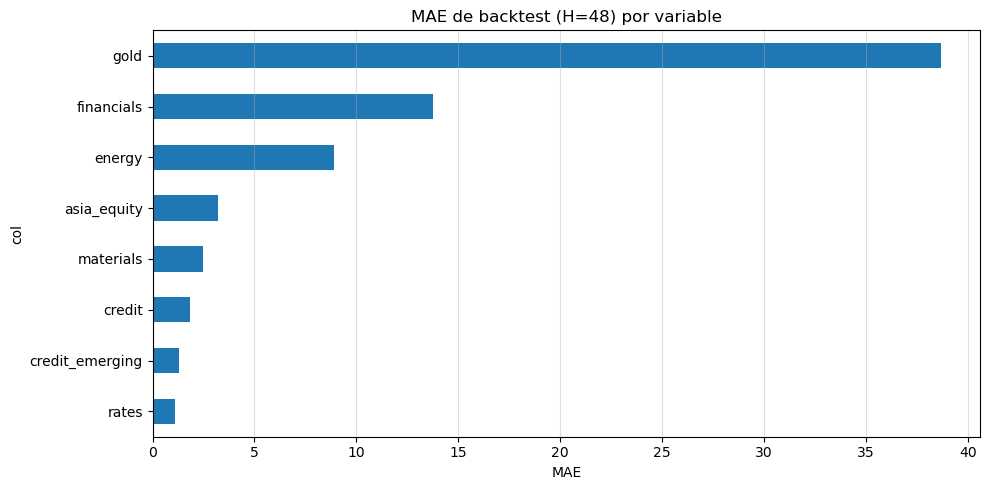

In [10]:
# ===== GRU univariante por columna (solo entrenamiento + validación) =====
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------------------------
# Configuración global básica
# ---------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_windows_1d(series_vals: np.ndarray, win: int):
    """
    Crea ventanas deslizantes para una serie 1D:
      X shape: (n_samples, win, 1)
      y shape: (n_samples, 1)
    """
    Xs, ys = [], []
    for t in range(len(series_vals) - win):
        Xs.append(series_vals[t:t+win])
        ys.append(series_vals[t+win])
    X = np.array(Xs, dtype=np.float32)[:, :, None]
    y = np.array(ys, dtype=np.float32)[:, None]
    return X, y

class GRUUni(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc  = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.gru(x)           # (batch, seq, hidden)
        last = out[:, -1, :]           # (batch, hidden)
        return self.fc(last)            # (batch, 1)

def train_validate_gru_for_series(
    series: pd.Series,
    win_size: int = 30,
    epochs: int = 50,
    batch_size: int = 64,
    lr: float = 1e-3,
    patience: int = 8,
    train_split: float = 0.8,
    use_log_returns: bool = True
):
    """
    Entrena y valida un GRU univariante para UNA columna (serie temporal).
    No devuelve predicciones a futuro; solo métricas en validación.
    """
    # 1) Preprocesamiento: serie -> retornos (opcional) -> split temporal
    s = series.dropna().astype(float)
    if use_log_returns:
        y_all = np.log(s).diff().dropna().values.astype(np.float32)
    else:
        y_all = s.values.astype(np.float32)

    if len(y_all) < win_size + 10:
        raise ValueError("Serie demasiado corta para la ventana elegida.")

    split_idx = int(len(y_all) * train_split)
    y_tr = y_all[:split_idx]
    y_va = y_all[split_idx:]

    # 2) Ventanas
    X_tr, t_tr = make_windows_1d(y_tr, win_size)
    X_va, t_va = make_windows_1d(y_va, win_size)

    # 3) Tensores y loaders
    train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(t_tr))
    valid_ds = TensorDataset(torch.tensor(X_va), torch.tensor(t_va))
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_dl = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

    # 4) Modelo, loss, optimizador
    model = GRUUni(hidden=32).to(DEVICE)
    loss_fn = nn.MSELoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # 5) Entrenamiento con early stopping (por val_loss)
    best_state, best_val, wait = None, float("inf"), 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

        # Validación
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in valid_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                pred = model(xb)
                val_loss += loss_fn(pred, yb).item() * len(xb)
        val_loss /= len(valid_ds)

        # Early stopping
        if val_loss < best_val - 1e-9:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    # 6) Cargar mejor estado y evaluar métricas en validación
    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in valid_dl:
            xb = xb.to(DEVICE)
            pred = model(xb).cpu().numpy().ravel()
            y_pred.append(pred)
            y_true.append(yb.numpy().ravel())

    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    metrics = {
        "best_val_mse": float(best_val),
        "rmse_val": float(rmse),
        "mae_val": float(mae),
        "n_train_samples": int(len(train_ds)),
        "n_valid_samples": int(len(valid_ds))
    }
    return metrics

# =========================
# Ejecutar para todo el df
# =========================
# df: tu DataFrame sin nulos y en orden temporal
cols = ['rates','financials','energy','credit_emerging','asia_equity','gold','credit','materials']
df_test = df.copy()
results = {}
for col in df_test.columns:
    print(f"\nEntrenando/validando GRU para: {col}")
    metrics = train_validate_gru_for_series(
        series=df[col],
        win_size=30,
        epochs=50,
        batch_size=64,
        lr=1e-3,
        patience=8,
        train_split=0.8,
        use_log_returns=True   # pon False si prefieres modelar el nivel directamente
    )
    results[col] = metrics
    print(metrics)

results_df = pd.DataFrame(results).T
print("\n===== Resumen de métricas (validación) =====")
print(results_df)

# ===== Pipeline unificado: Barras de validación -> Predicciones -> Barras de backtest =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------------- Parametros ----------------
H        = 48   # horizonte del backtest (últimos H puntos a predecir)
WIN      = 30   # ventana (timesteps) para el modelo
EPOCHS   = 40
BATCH    = 64
LR       = 1e-3
HIDDEN   = 32
VAL_FRAC = 0.15   # fracción del set de entrenamiento para validación interna
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------- Utilidades -------------
def make_windows_1d(values: np.ndarray, win: int):
    X, y = [], []
    for i in range(len(values) - win):
        X.append(values[i:i+win])
        y.append(values[i+win])
    X = np.asarray(X, dtype=np.float32)[:, :, None]   # (n, win, 1)
    y = np.asarray(y, dtype=np.float32)[:, None]      # (n, 1)
    return X, y

class GRUUni(nn.Module):
    def __init__(self, hidden=HIDDEN):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc  = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        last = out[:, -1, :]
        return self.fc(last)

def fit_gru_with_internal_val(series_train_scaled: np.ndarray,
                              win=WIN, epochs=EPOCHS, batch=BATCH, lr=LR, val_frac=VAL_FRAC):
    """
    Entrena GRU con validación interna (último % del entrenamiento).
    Devuelve: model entrenado, (y_val_true, y_val_pred) en escala ESCALADA.
    """
    X_all, y_all = make_windows_1d(series_train_scaled, win)
    n = len(X_all)
    n_val = max(int(n * val_frac), 1)
    n_tr  = max(n - n_val, 1)

    X_tr, y_tr = X_all[:n_tr], y_all[:n_tr]
    X_va, y_va = X_all[n_tr:], y_all[n_tr:]

    train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
    valid_ds = TensorDataset(torch.tensor(X_va), torch.tensor(y_va))
    train_dl = DataLoader(train_ds, batch_size=batch, shuffle=True)
    valid_dl = DataLoader(valid_ds, batch_size=batch, shuffle=False)

    model = GRUUni().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_state, best_val, wait, patience = None, float("inf"), 0, 8
    for _ in range(epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        # validación
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in valid_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_loss += loss_fn(model(xb), yb).item() * len(xb)
        val_loss /= max(len(valid_ds), 1)
        if val_loss < best_val - 1e-9:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # y_val_pred para métricas
    model.eval()
    y_val_true, y_val_pred = [], []
    with torch.no_grad():
        for xb, yb in valid_dl:
            xb = xb.to(DEVICE)
            pred = model(xb).cpu().numpy().ravel()
            y_val_pred.append(pred)
            y_val_true.append(yb.numpy().ravel())
    if len(y_val_true) == 0:
        y_val_true = np.array([])
        y_val_pred = np.array([])
    else:
        y_val_true = np.concatenate(y_val_true)
        y_val_pred = np.concatenate(y_val_pred)
    return model, y_val_true, y_val_pred

def forecast_recursive_scaled(model: nn.Module, last_window_scaled: np.ndarray, horizon: int):
    """Predice recursivamente 'horizon' pasos en ESCALA escalada."""
    model.eval()
    window = last_window_scaled.copy()   # (win, 1)
    preds = []
    with torch.no_grad():
        for _ in range(horizon):
            x = torch.tensor(window[None, ...], dtype=torch.float32, device=DEVICE)  # (1, win, 1)
            yhat = model(x).cpu().numpy().ravel()[0]
            preds.append(yhat)
            window = np.vstack([window[1:], [[yhat]]])
    return np.array(preds, dtype=np.float32)

# ------------- Entrenamiento + Validación + Backtest por columna -------------
val_rows   = []   # métricas validación interna
test_rows  = []   # métricas backtest
plot_cache = {}   # para graficar después: train/test/pred

for col in df.columns:
    s = df[col].dropna().astype(float)
    if len(s) < WIN + H + 10:
        print(f"Saltando {col}: serie demasiado corta para WIN={WIN}, H={H}.")
        continue

    # Split backtest: train (todo menos H), test (últimos H)
    s_train = s.iloc[:-H].copy()
    s_test  = s.iloc[-H:].copy()

    # Escalado en niveles (fit solo con train)
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(s_train.values.reshape(-1, 1)).astype(np.float32).ravel()
    test_scaled  = scaler.transform(s_test.values.reshape(-1, 1)).astype(np.float32).ravel()

    # (A) Entrenar con validación interna
    model, yv_true_sc, yv_pred_sc = fit_gru_with_internal_val(train_scaled, WIN, EPOCHS, BATCH, LR, VAL_FRAC)

    # Métricas de validación (en escala original)
    if yv_true_sc.size > 0:
        yv_true = scaler.inverse_transform(yv_true_sc.reshape(-1, 1)).ravel()
        yv_pred = scaler.inverse_transform(yv_pred_sc.reshape(-1, 1)).ravel()
        rmse_val = np.sqrt(mean_squared_error(yv_true, yv_pred))
        mae_val  = mean_absolute_error(yv_true, yv_pred)
    else:
        rmse_val, mae_val = np.nan, np.nan
    val_rows.append({"col": col, "rmse_val": rmse_val, "mae_val": mae_val})

    # (B) Backtest: predecir últimos H recursivo
    last_window = train_scaled[-WIN:].reshape(-1, 1)                # (WIN, 1)
    pred_sc = forecast_recursive_scaled(model, last_window, horizon=H)
    pred = scaler.inverse_transform(pred_sc.reshape(-1, 1)).ravel()

    rmse_H = np.sqrt(mean_squared_error(s_test.values, pred))
    mae_H  = mean_absolute_error(s_test.values, pred)
    test_rows.append({"col": col, "rmse_H": rmse_H, "mae_H": mae_H})

    # Guardar para graficar después
    plot_cache[col] = {
        "train_vals": s_train.values,
        "test_vals":  s_test.values,
        "pred_vals":  pred
    }

# ------------ Tablas resumen ------------
results_val_df  = pd.DataFrame(val_rows).set_index("col").sort_values("rmse_val")
results_test_df = pd.DataFrame(test_rows).set_index("col").sort_values("rmse_H")

# ============================================================
# 1) BARRAS DE ENTRENAMIENTO/VALIDACIÓN (antes de predicciones)
# ============================================================
print("\n===== Validación interna (menor RMSE mejor) =====")
print(results_val_df[["rmse_val", "mae_val"]])

plt.figure(figsize=(10,5))
results_val_df["rmse_val"].sort_values().plot(kind='barh')
plt.title("RMSE de validación por variable")
plt.xlabel("RMSE")
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
results_val_df["mae_val"].sort_values().plot(kind='barh')
plt.title("MAE de validación por variable")
plt.xlabel("MAE")
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

# ==========================================
# 2) GRÁFICOS DE PREDICCIONES (backtest H)
# ==========================================
for col, d in plot_cache.items():
    train_len = len(d["train_vals"])
    H_local   = len(d["test_vals"])  # por si alguna serie tiene H ligeramente distinto
    plt.figure(figsize=(8,4))
    plt.plot(range(train_len), d["train_vals"], label="Train", alpha=0.5)
    plt.plot(range(train_len, train_len+H_local), d["test_vals"], label="Real (Test)", linewidth=2)
    plt.plot(range(train_len, train_len+H_local), d["pred_vals"], label="Predicción GRU", linestyle="--", linewidth=2)
    plt.title(f"{col} — Backtest: últimos {H_local}")
    plt.xlabel("Tiempo (índice secuencial)")
    plt.ylabel("Valor")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==========================================
# 3) BARRAS DE PREDICCIÓN (backtest H)
# ==========================================
df_gru1 = results_test_df.copy()
df_gru2 = results_val_df.copy()

print("\n===== Backtest H pasos (menor RMSE mejor) =====")
print(results_test_df[["rmse_H", "mae_H"]])

plt.figure(figsize=(10,5))
results_test_df["rmse_H"].sort_values().plot(kind='barh')
plt.title(f"RMSE de backtest (H={H}) por variable")
plt.xlabel("RMSE")
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
results_test_df["mae_H"].sort_values().plot(kind='barh')
plt.title(f"MAE de backtest (H={H}) por variable")
plt.xlabel("MAE")
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

In [11]:
plot_cache_gru = plot_cache.copy()

# Random Forrest


===== Validación interna (menor RMSE mejor) =====
                  rmse_val    mae_val
col                                  
rates             0.453025   0.362493
credit_emerging   0.520481   0.394136
asia_equity       1.182748   0.893062
materials         2.453912   1.969988
credit            5.085345   4.475565
energy           12.681431  10.388483
financials       22.282500  17.013096
gold             39.899513  30.431689


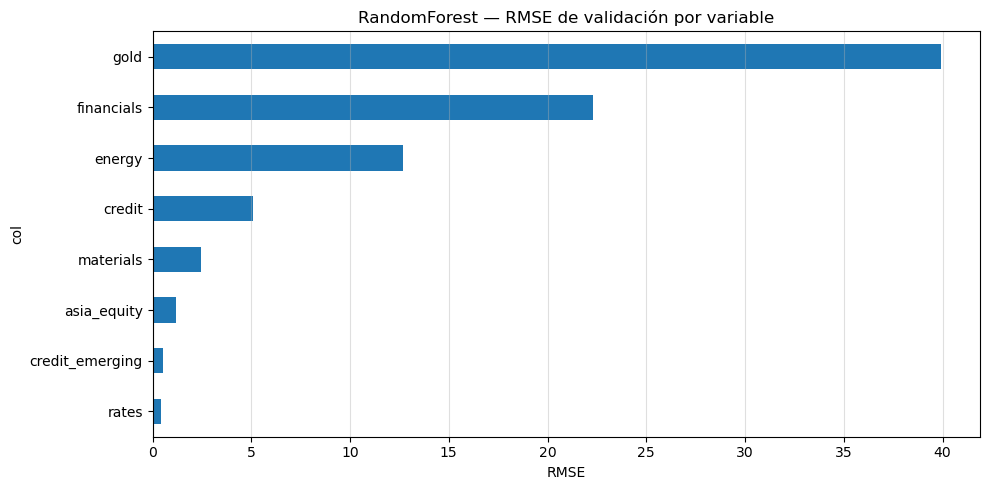

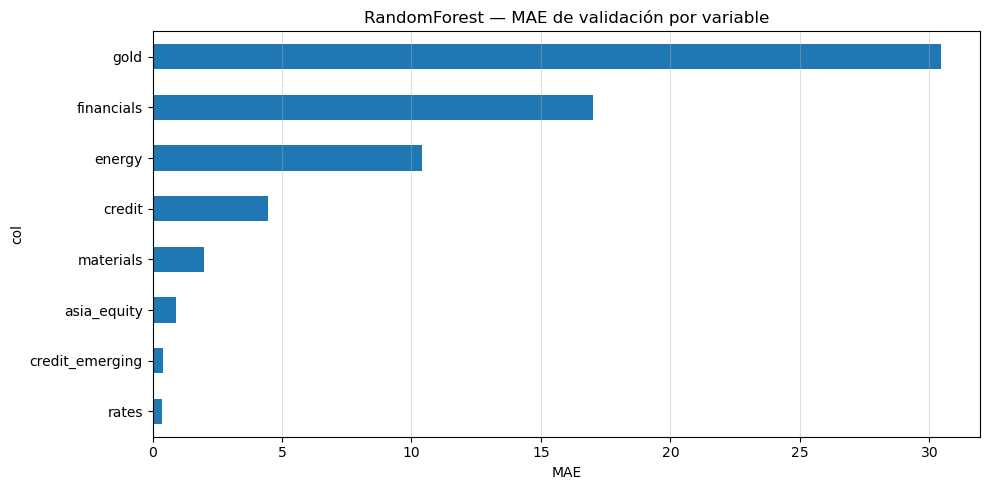

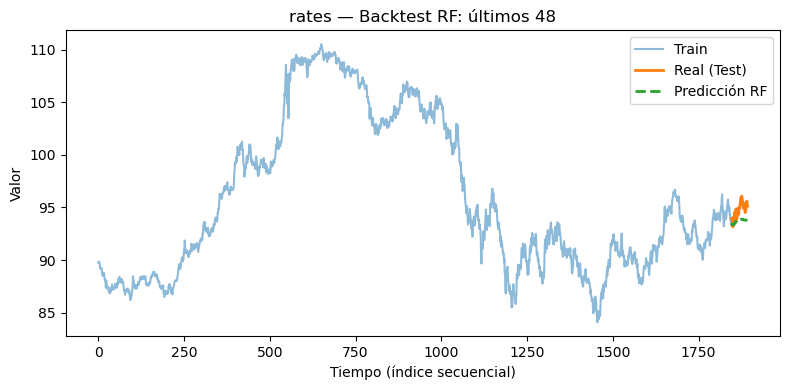

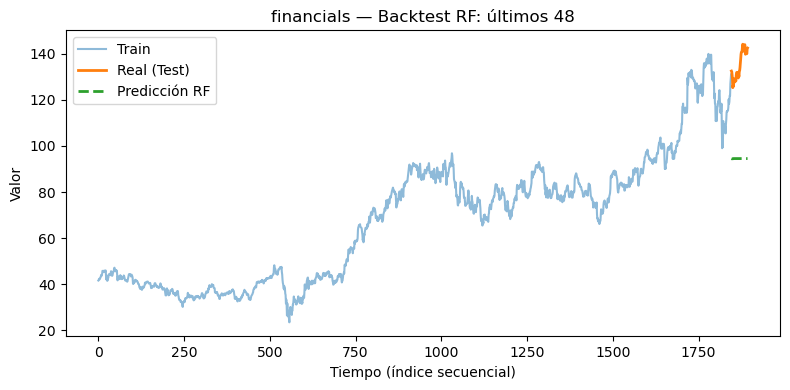

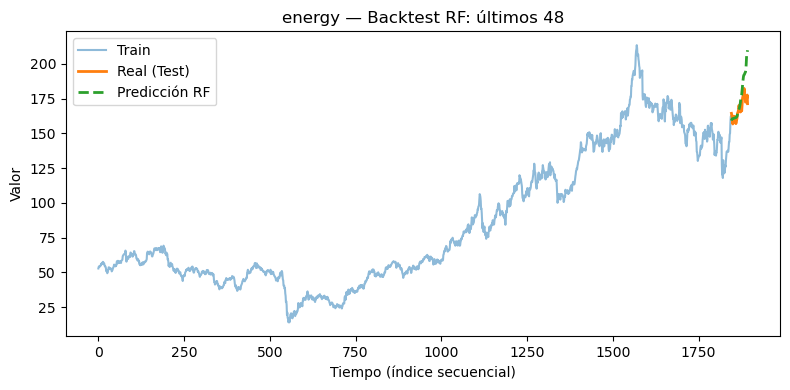

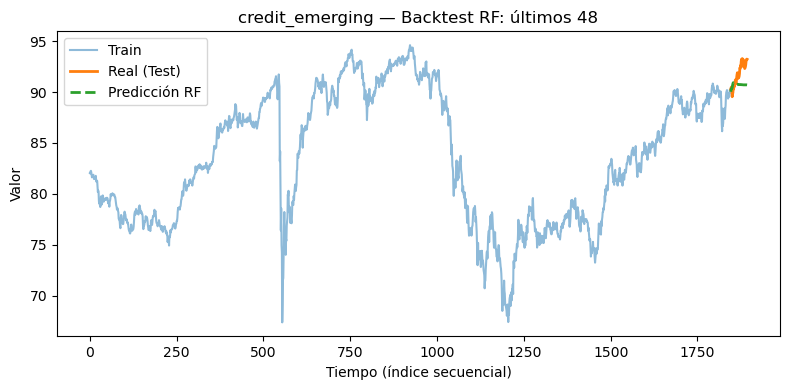

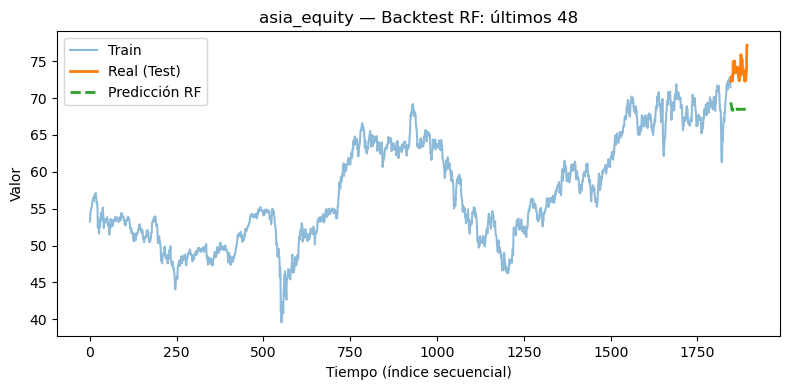

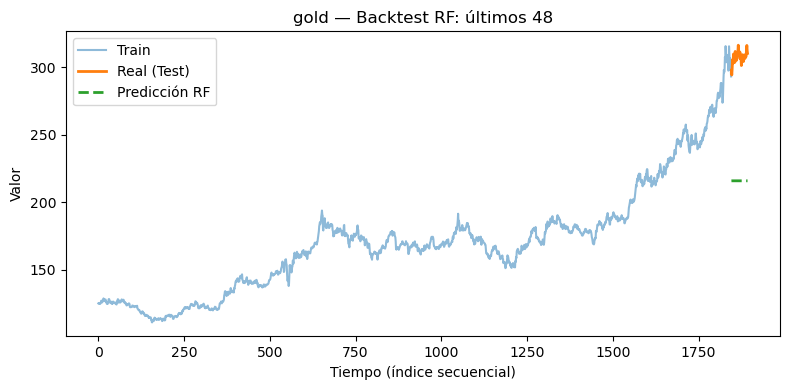

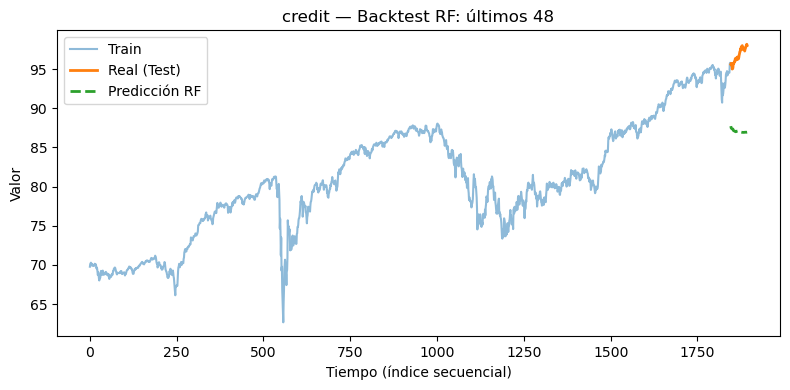

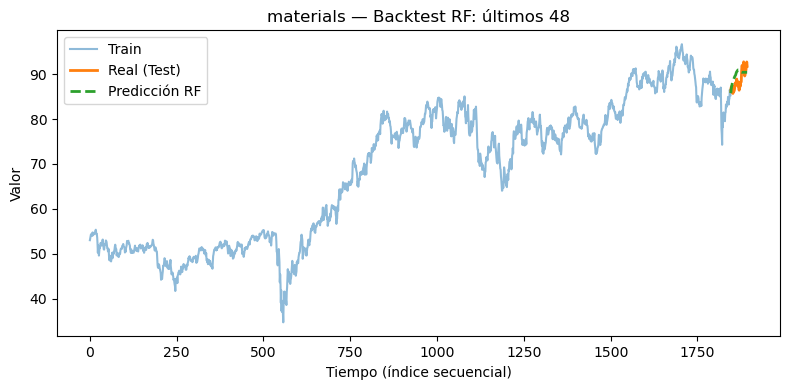


===== Backtest H pasos (menor RMSE mejor) =====
                    rmse_H      mae_H
col                                  
rates             1.174993   1.039958
credit_emerging   1.503431   1.239370
materials         2.163929   1.892243
asia_equity       5.353605   5.215318
credit            9.784508   9.725849
energy           12.905181   8.564721
financials       41.070693  40.634290
gold             91.590610  91.493035


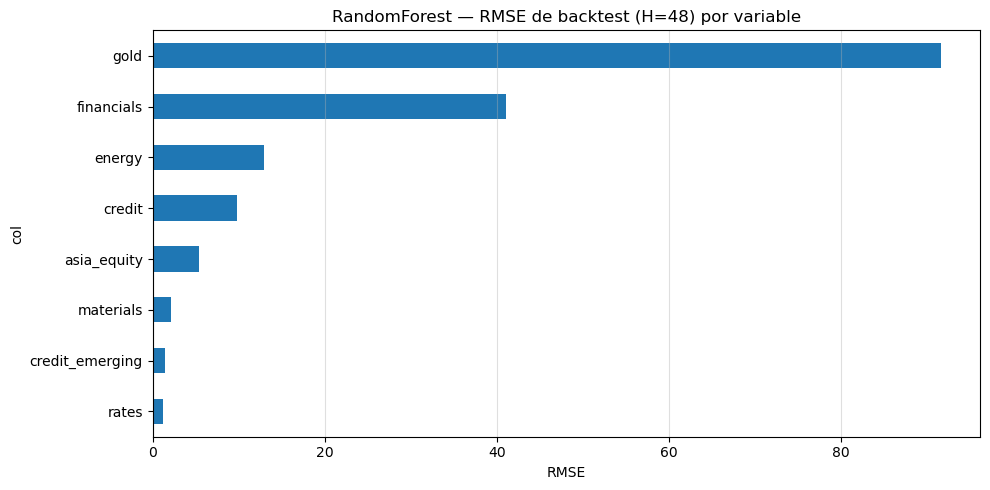

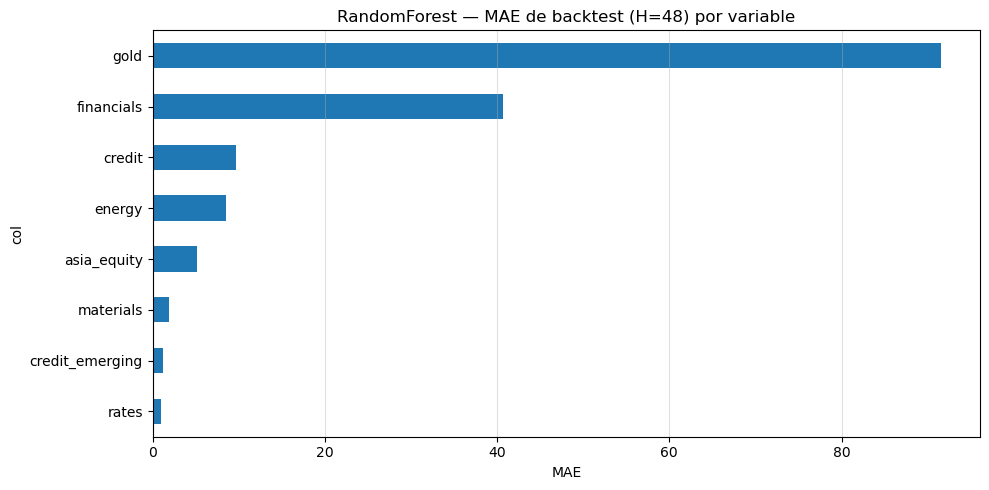

In [12]:
# ===== Pipeline unificado con RandomForest: Validación -> Predicciones -> Barras backtest =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.utils.validation import check_is_fitted

# ---------------- Parámetros ----------------
H        = 48   # horizonte del backtest: últimos H puntos a predecir
WIN      = 30   # nº de rezagos (timesteps) como features
VAL_FRAC = 0.15 # fracción del set de entrenamiento para validación interna
RF_KW    = dict(n_estimators=400, max_depth=None, n_jobs=-1, random_state=0)

# ------------- Utilidades -------------
def make_supervised_from_series(values: np.ndarray, lags: int):
    """
    Convierte una serie 1D en dataset supervisado con rezagos:
      X[i] = [y_{i-lags}, ..., y_{i-1}]
      y[i] = y_i
    Devuelve X (n-samples, lags) y y (n-samples,)
    """
    y = np.asarray(values, dtype=float).ravel()
    if len(y) <= lags:
        return np.empty((0, lags)), np.empty((0,))
    X = np.column_stack([y[k: len(y) - lags + k] for k in range(lags)])  # columnas: lag WIN..1
    X = X[:, ::-1]  # ordenar de más reciente a más antiguo [lag1, lag2, ..., lagWIN]
    y_out = y[lags:]
    return X.astype(np.float32), y_out.astype(np.float32)

def split_internal_validation(X, y, val_frac: float):
    """
    Separa al final del set para validación interna (temporal).
    """
    n = len(X)
    n_val = max(int(n * val_frac), 1)
    n_tr  = max(n - n_val, 1)
    return (X[:n_tr], y[:n_tr]), (X[n_tr:], y[n_tr:])

def fit_rf_with_internal_val(series_train: pd.Series, lags: int, val_frac: float, rf_params: dict):
    """
    Entrena RandomForest con validación interna al final del set de entrenamiento.
    Devuelve:
      - modelo entrenado,
      - y_val_true, y_val_pred (para métricas de validación)
    """
    X_all, y_all = make_supervised_from_series(series_train.values, lags)
    if len(X_all) < 2:
        # demasiados pocos ejemplos
        return None, np.array([]), np.array([])

    (X_tr, y_tr), (X_va, y_va) = split_internal_validation(X_all, y_all, val_frac)

    rf = RandomForestRegressor(**rf_params)
    rf.fit(X_tr, y_tr)

    y_va_pred = rf.predict(X_va) if len(X_va) > 0 else np.array([])
    return rf, y_va, y_va_pred

def forecast_recursive_rf(model: RandomForestRegressor, last_window: np.ndarray, horizon: int):
    """
    Predice recursivamente 'horizon' pasos.
    last_window: array shape (WIN,) con los últimos WIN valores (lag1..lagWIN, lag1 el más reciente).
    """
    preds = []
    window = last_window.astype(np.float32).copy()
    for _ in range(horizon):
        x = window.reshape(1, -1)
        yhat = float(model.predict(x))
        preds.append(yhat)
        # actualizar ventana: desplazamiento y anexar el nuevo predicho como lag1
        window = np.roll(window, 1)
        window[0] = yhat
    return np.array(preds, dtype=np.float32)

# ------------- Entrenamiento + Validación + Backtest por columna -------------
val_rows   = []   # métricas de validación
test_rows  = []   # métricas de backtest
plot_cache = {}   # para graficar después

for col in df.columns:
    s = df[col].dropna().astype(float)
    if len(s) < WIN + H + 10:
        print(f"Saltando {col}: serie demasiado corta para WIN={WIN}, H={H}.")
        continue

    # Split backtest: train = todo menos H, test = últimos H
    s_train = s.iloc[:-H].copy()
    s_test  = s.iloc[-H:].copy()

    # (A) Entrenar RF con validación interna en el set de entrenamiento
    model, yv_true, yv_pred = fit_rf_with_internal_val(s_train, lags=WIN, val_frac=VAL_FRAC, rf_params=RF_KW)

    if model is None:
        print(f"Saltando {col}: no se pudo entrenar (pocos ejemplos).")
        continue

    # Métricas de validación (en niveles)
    if yv_true.size > 0 and yv_pred.size > 0:
        rmse_val = np.sqrt(mean_squared_error(yv_true, yv_pred))
        mae_val  = mean_absolute_error(yv_true, yv_pred)
    else:
        rmse_val, mae_val = np.nan, np.nan
    val_rows.append({"col": col, "rmse_val": rmse_val, "mae_val": mae_val})

    # (B) Backtest: predecir últimos H puntos recursivamente
    # preparar última ventana de entrenamiento (lag1..lagWIN: más reciente primero)
    last_window = s_train.values[-WIN:][::-1]  # [lag1, lag2, ..., lagWIN]
    pred = forecast_recursive_rf(model, last_window, horizon=H)

    rmse_H = np.sqrt(mean_squared_error(s_test.values, pred))
    mae_H  = mean_absolute_error(s_test.values, pred)
    test_rows.append({"col": col, "rmse_H": rmse_H, "mae_H": mae_H})

    # Cache para gráficos
    plot_cache[col] = {
        "train_vals": s_train.values,
        "test_vals":  s_test.values,
        "pred_vals":  pred
    }

# ------------ Tablas resumen ------------
results_val_df  = pd.DataFrame(val_rows).set_index("col").sort_values("rmse_val")
results_test_df = pd.DataFrame(test_rows).set_index("col").sort_values("rmse_H")

# ============================================================
# 1) BARRAS DE ENTRENAMIENTO/VALIDACIÓN (antes de predicciones)
# ============================================================
print("\n===== Validación interna (menor RMSE mejor) =====")
print(results_val_df[["rmse_val", "mae_val"]])

plt.figure(figsize=(10,5))
results_val_df["rmse_val"].sort_values().plot(kind='barh')
plt.title("RandomForest — RMSE de validación por variable")
plt.xlabel("RMSE")
plt.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
results_val_df["mae_val"].sort_values().plot(kind='barh')
plt.title("RandomForest — MAE de validación por variable")
plt.xlabel("MAE")
plt.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

# ==========================================
# 2) GRÁFICOS DE PREDICCIONES (backtest H)
# ==========================================
for col, d in plot_cache.items():
    train_len = len(d["train_vals"])
    H_local   = len(d["test_vals"])
    plt.figure(figsize=(8,4))
    plt.plot(range(train_len), d["train_vals"], label="Train", alpha=0.5)
    plt.plot(range(train_len, train_len+H_local), d["test_vals"], label="Real (Test)", linewidth=2)
    plt.plot(range(train_len, train_len+H_local), d["pred_vals"], label="Predicción RF", linestyle="--", linewidth=2)
    plt.title(f"{col} — Backtest RF: últimos {H_local}")
    plt.xlabel("Tiempo (índice secuencial)")
    plt.ylabel("Valor")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==========================================
# 3) BARRAS DE PREDICCIÓN (backtest H)
# ==========================================
print("\n===== Backtest H pasos (menor RMSE mejor) =====")
print(results_test_df[["rmse_H", "mae_H"]])

df_randomForest1 = results_test_df.copy()
df_randomForest2 = results_val_df.copy()

plt.figure(figsize=(10,5))
results_test_df["rmse_H"].sort_values().plot(kind='barh')
plt.title(f"RandomForest — RMSE de backtest (H={H}) por variable")
plt.xlabel("RMSE")
plt.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
results_test_df["mae_H"].sort_values().plot(kind='barh')
plt.title(f"RandomForest — MAE de backtest (H={H}) por variable")
plt.xlabel("MAE")
plt.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

In [13]:
plot_cache_rf = plot_cache.copy()

# XGBoost


===== Validación interna (menor RMSE mejor) =====
                  rmse_val    mae_val   modelo
col                                           
rates             0.412006   0.327921  XGBoost
credit_emerging   0.509182   0.352059  XGBoost
asia_equity       1.311562   0.974622  XGBoost
materials         2.621320   1.909535  XGBoost
credit            2.639298   2.455027  XGBoost
energy            4.553596   3.476760  XGBoost
financials       24.525238  20.927855  XGBoost
gold             36.935439  29.657265  XGBoost


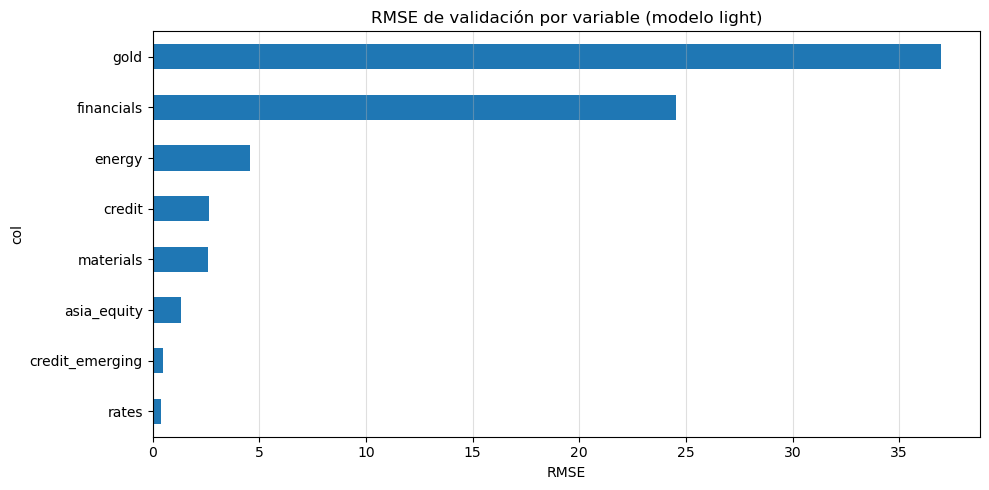

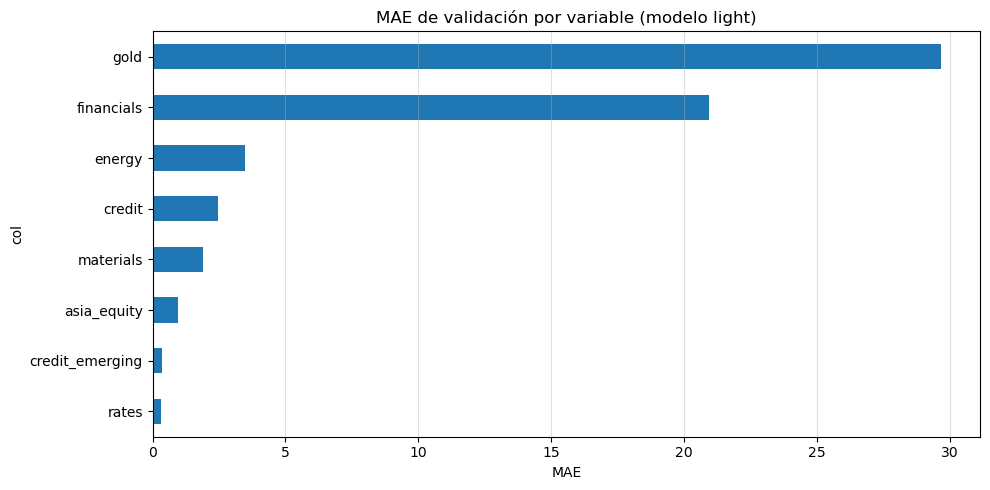

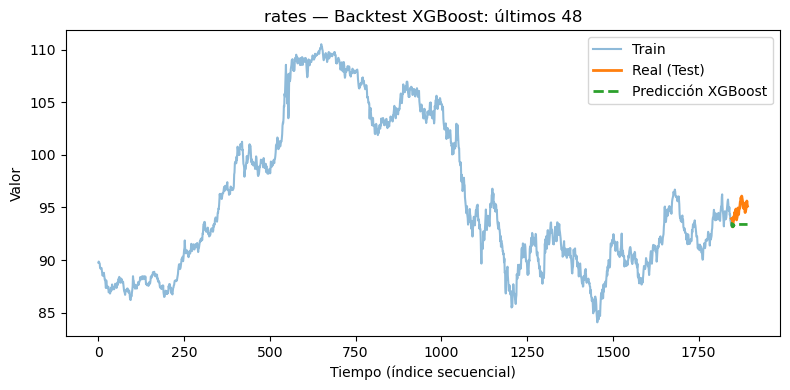

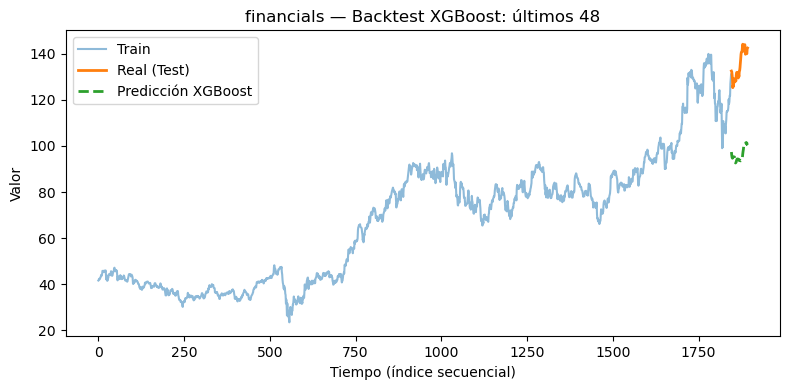

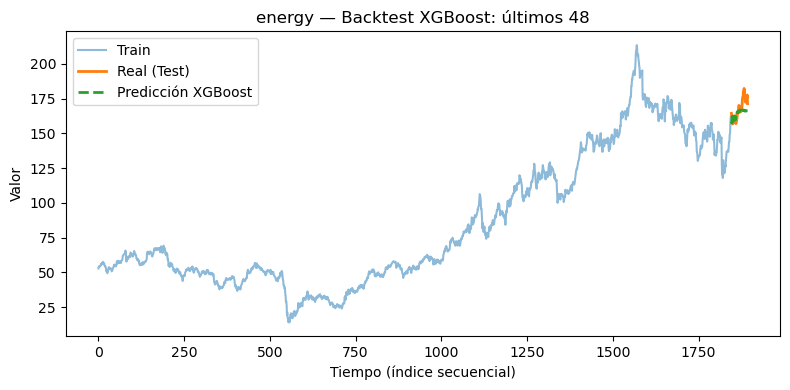

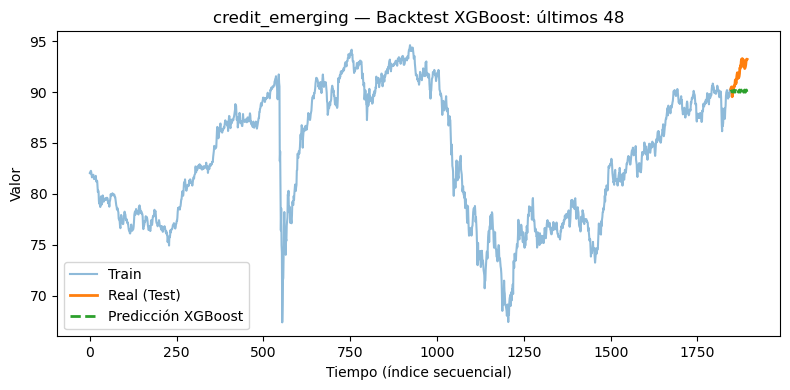

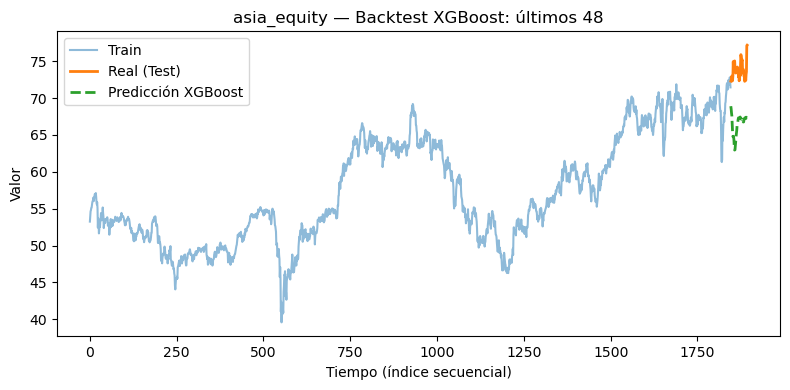

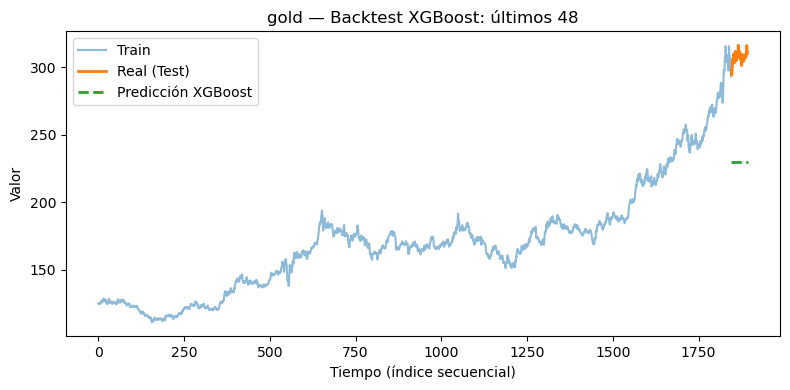

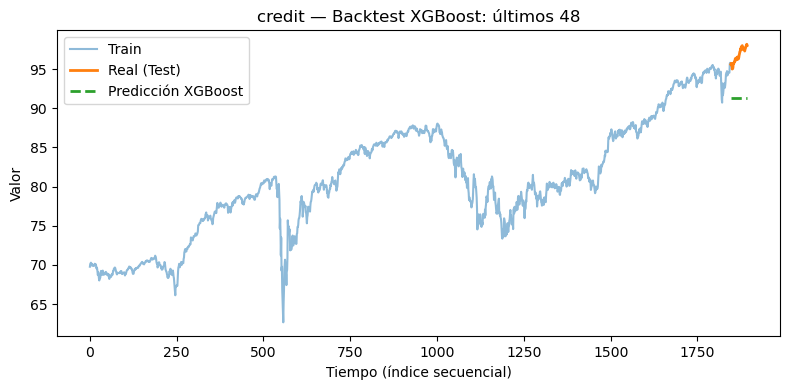

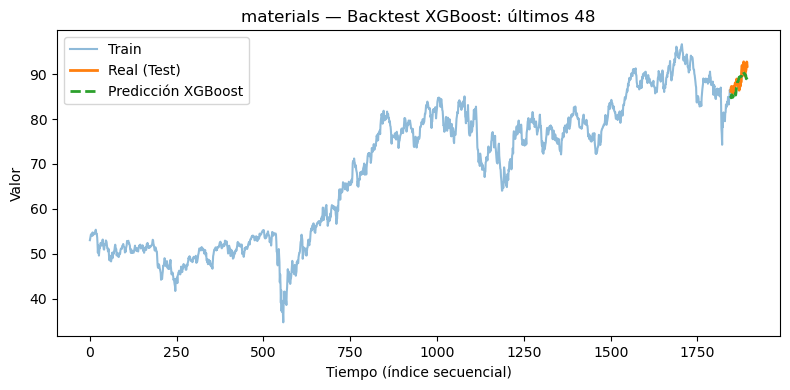


===== Backtest H pasos (menor RMSE mejor) =====
                    rmse_H      mae_H   modelo
col                                           
rates             1.531247   1.378928  XGBoost
materials         1.730073   1.512881  XGBoost
credit_emerging   1.985073   1.694981  XGBoost
credit            5.580781   5.504303  XGBoost
energy            6.305943   4.626746  XGBoost
asia_equity       7.569759   7.304314  XGBoost
financials       39.306269  39.030807  XGBoost
gold             77.933052  77.818321  XGBoost


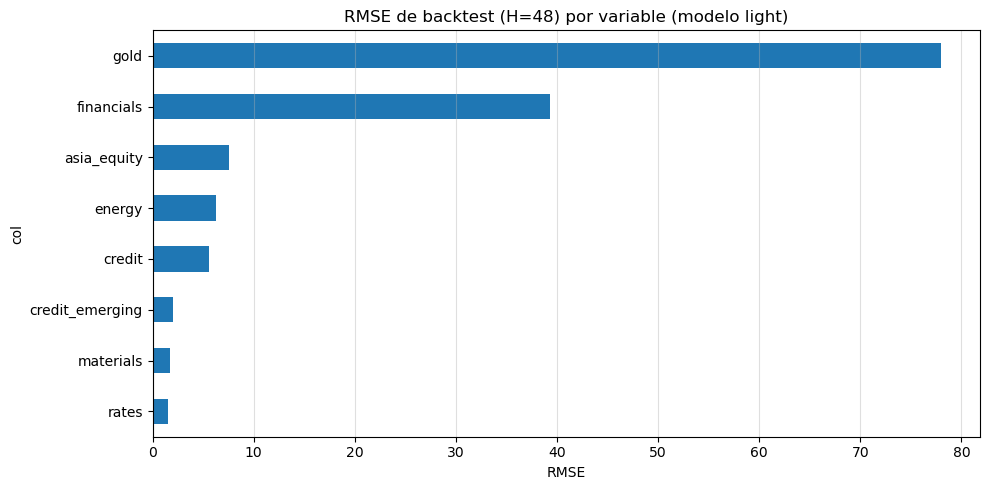

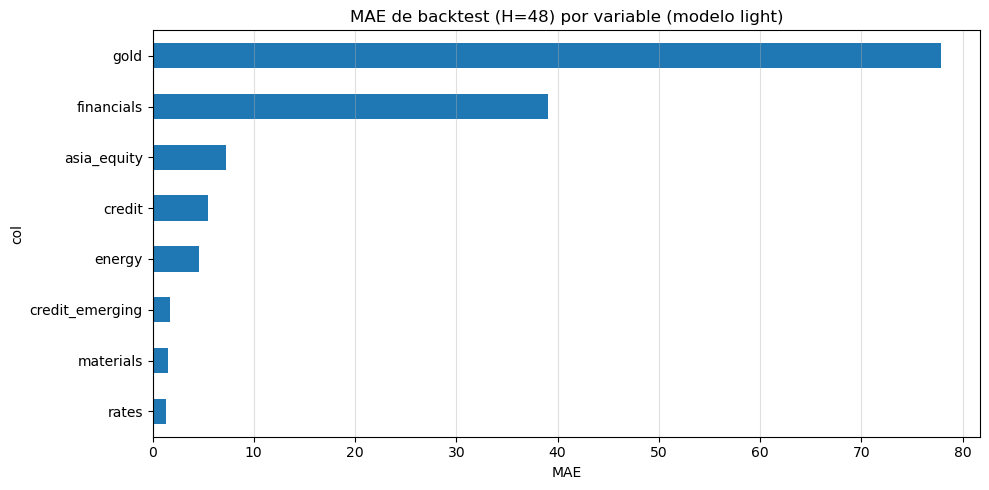

In [14]:
# ===== XGBoost liviano (con fallback a RandomForest) — Validación -> Predicciones -> Barras backtest =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor


# ---------------- Parámetros anti-kernel-crash ----------------
H         = 48     # horizonte del backtest
WIN       = 24     # rezagos como features (bájalo si hay poco RAM)
VAL_FRAC  = 0.10   # parte final del train para validación interna
TAIL_N    = 4000   # usa sólo la cola reciente por serie (None para desactivar)
USE_RF_IF_XGB_FAILS = True  # fallback automático si XGB no está o falla

# XGBoost "super light"
XGB_KW = dict(
    n_estimators=200,
    learning_rate=0.08,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=0,
    n_jobs=1,             # limita CPUs
)
# RandomForest "light" (fallback)
RF_KW = dict(
    n_estimators=300,
    max_depth=None,
    n_jobs=1,
    random_state=0
)

# ---------- Utilidades ----------
def make_supervised_from_series(values: np.ndarray, lags: int):
    y = np.asarray(values, dtype=np.float32).ravel()
    if len(y) <= lags:
        return np.empty((0, lags), np.float32), np.empty((0,), np.float32)
    X = np.column_stack([y[k: len(y) - lags + k] for k in range(lags)]).astype(np.float32)  # lag WIN..1
    X = X[:, ::-1].astype(np.float32)  # [lag1..lagWIN]
    y_out = y[lags:].astype(np.float32)
    return X, y_out

def split_internal_validation(X, y, val_frac: float):
    n = len(X)
    n_val = max(int(n * val_frac), 1)
    n_tr  = max(n - n_val, 1)
    return (X[:n_tr], y[:n_tr]), (X[n_tr:], y[n_tr:])

def fit_model_with_internal_val(series_train: pd.Series, lags: int, val_frac: float):
    """
    Intenta XGBoost primero; si falla/ausente y USE_RF_IF_XGB_FAILS=True, usa RF.
    Devuelve: model, y_val_true, y_val_pred, model_name
    """
    X_all, y_all = make_supervised_from_series(series_train.values, lags)
    if len(X_all) < 2:
        return None, np.array([]), np.array([]), "None"

    (X_tr, y_tr), (X_va, y_va) = split_internal_validation(X_all, y_all, val_frac)

    # intenta XGBoost light
    model_name = "XGBoost"
    try:
        from xgboost import XGBRegressor
        model = XGBRegressor(**XGB_KW)
        model.fit(X_tr, y_tr, verbose=False)  # compatible con versiones viejas
        y_va_pred = model.predict(X_va) if len(X_va) > 0 else np.array([])
        return model, y_va, y_va_pred, model_name
    except Exception as e:
        if not USE_RF_IF_XGB_FAILS:
            raise
        # fallback a RF
        model_name = "RandomForest (fallback)"
        model = RandomForestRegressor(**RF_KW)
        model.fit(X_tr, y_tr)
        y_va_pred = model.predict(X_va) if len(X_va) > 0 else np.array([])
        return model, y_va, y_va_pred, model_name

def forecast_recursive(model, last_window: np.ndarray, horizon: int):
    """
    Predicción recursiva horizon pasos. last_window: (WIN,) con [lag1..lagWIN], lag1=más reciente.
    """
    preds = []
    window = last_window.astype(np.float32).copy()
    for _ in range(horizon):
        yhat = float(model.predict(window.reshape(1, -1)))
        preds.append(yhat)
        window = np.roll(window, 1)
        window[0] = yhat
    return np.array(preds, dtype=np.float32)

# ---------- Entrenamiento + Validación + Backtest ----------
val_rows   = []
test_rows  = []
plot_cache = {}
model_used = {}

for col in df.columns:
    s = df[col].dropna().astype(np.float32)
    if TAIL_N is not None and len(s) > TAIL_N:
        s = s.iloc[-TAIL_N:]  # recorta cola para ahorrar RAM/tiempo

    if len(s) < WIN + H + 10:
        print(f"Saltando {col}: serie demasiado corta para WIN={WIN}, H={H}.")
        continue

    # Split backtest
    s_train = s.iloc[:-H].copy()
    s_test  = s.iloc[-H:].copy()

    # (A) Entrenar con validación interna (temporal)
    model, yv_true, yv_pred, name = fit_model_with_internal_val(s_train, lags=WIN, val_frac=VAL_FRAC)
    model_used[col] = name
    if model is None:
        print(f"Saltando {col}: no se pudo entrenar.")
        continue

    # Métricas de validación
    if yv_true.size > 0 and yv_pred.size > 0:
        rmse_val = np.sqrt(mean_squared_error(yv_true, yv_pred))
        mae_val  = mean_absolute_error(yv_true, yv_pred)
    else:
        rmse_val, mae_val = np.nan, np.nan
    val_rows.append({"col": col, "rmse_val": rmse_val, "mae_val": mae_val, "modelo": name})

    # (B) Backtest: predicción recursiva de los últimos H
    last_window = s_train.values[-WIN:][::-1]  # [lag1..lagWIN]
    pred = forecast_recursive(model, last_window, horizon=H)

    rmse_H = np.sqrt(mean_squared_error(s_test.values, pred))
    mae_H  = mean_absolute_error(s_test.values, pred)
    test_rows.append({"col": col, "rmse_H": rmse_H, "mae_H": mae_H, "modelo": name})

    # Cache gráfico
    plot_cache[col] = {"train_vals": s_train.values, "test_vals": s_test.values, "pred_vals": pred}

    # limpieza intermedia
    del model, yv_true, yv_pred, last_window, pred
    gc.collect()

# ------------ Tablas resumen ------------
results_val_df  = pd.DataFrame(val_rows).set_index("col").sort_values("rmse_val")
results_test_df = pd.DataFrame(test_rows).set_index("col").sort_values("rmse_H")

# ============================================================
# 1) BARRAS DE ENTRENAMIENTO/VALIDACIÓN (antes de predicciones)
# ============================================================
print("\n===== Validación interna (menor RMSE mejor) =====")
print(results_val_df[["rmse_val", "mae_val", "modelo"]])

plt.figure(figsize=(10,5))
results_val_df["rmse_val"].sort_values().plot(kind='barh')
plt.title("RMSE de validación por variable (modelo light)")
plt.xlabel("RMSE")
plt.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
results_val_df["mae_val"].sort_values().plot(kind='barh')
plt.title("MAE de validación por variable (modelo light)")
plt.xlabel("MAE")
plt.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

# ==========================================
# 2) GRÁFICOS DE PREDICCIONES (backtest H)
# ==========================================
for col, d in plot_cache.items():
    train_len = len(d["train_vals"])
    H_local   = len(d["test_vals"])
    plt.figure(figsize=(8,4))
    plt.plot(range(train_len), d["train_vals"], label="Train", alpha=0.5)
    plt.plot(range(train_len, train_len+H_local), d["test_vals"], label="Real (Test)", linewidth=2)
    plt.plot(range(train_len, train_len+H_local), d["pred_vals"], label=f"Predicción {model_used[col]}", linestyle="--", linewidth=2)
    plt.title(f"{col} — Backtest {model_used[col]}: últimos {H_local}")
    plt.xlabel("Tiempo (índice secuencial)")
    plt.ylabel("Valor")
    plt.legend()
    plt.tight_layout()
    plt.show()

df_xgBoost1 = results_test_df.copy()
df_xgBoost2 = results_val_df.copy()

# ==========================================
# 3) BARRAS DE PREDICCIÓN (backtest H)
# ==========================================
print("\n===== Backtest H pasos (menor RMSE mejor) =====")
print(results_test_df[["rmse_H", "mae_H", "modelo"]])

plt.figure(figsize=(10,5))
results_test_df["rmse_H"].sort_values().plot(kind='barh')
plt.title(f"RMSE de backtest (H={H}) por variable (modelo light)")
plt.xlabel("RMSE")
plt.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
results_test_df["mae_H"].sort_values().plot(kind='barh')
plt.title(f"MAE de backtest (H={H}) por variable (modelo light)")
plt.xlabel("MAE")
plt.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

In [15]:
plot_cache_xgb = plot_cache.copy()

# Aplicacion

In [16]:
print(df_gru1.head())
print("="*50)
print(df_gru2.head())
print("="*50)
print(df_randomForest1.head())
print("="*50)
print(df_randomForest2.head())
print("="*50)
print(df_xgBoost1.head())
print("="*50)
print(df_xgBoost2.head())

                   rmse_H     mae_H
col                                
rates            1.274575  1.097516
credit_emerging  1.547046  1.307088
credit           2.128165  1.846830
materials        3.154483  2.477264
asia_equity      3.489435  3.202726
                 rmse_val   mae_val
col                                
credit           0.437111  0.298574
rates            0.530024  0.419437
credit_emerging  0.555529  0.422592
asia_equity      1.171235  0.841064
materials        1.399226  1.008227
                   rmse_H     mae_H
col                                
rates            1.174993  1.039958
credit_emerging  1.503431  1.239370
materials        2.163929  1.892243
asia_equity      5.353605  5.215318
credit           9.784508  9.725849
                 rmse_val   mae_val
col                                
rates            0.453025  0.362493
credit_emerging  0.520481  0.394136
asia_equity      1.182748  0.893062
materials        2.453912  1.969988
credit           5.085345  4

In [17]:
# ============================================
#  CELDA 1: FUNCIONES Y PREPARACIÓN DE DATOS
# ============================================
from jupyter_dash import JupyterDash
from dash import html, dcc, Input, Output
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

# ---------------------------
#   PALETA DE COLORES
# ---------------------------
COLOR_BG = "#0D1317"      # Fondo general
COLOR_TEXT = "#FFFFFF"    # Texto
C_MALACHITE = "#04E762"   # Verde
C_PHLOX = "#D63AF9"       # Magenta
C_URAN = "#A9CEF4"        # Azul claro
C_SCARLET = "#F42C04"     # Rojo

color_map = {
    'rates': C_MALACHITE,
    'financials': C_PHLOX,
    'energy': C_URAN,
    'credit_emerging': C_SCARLET,
    'asia_equity': C_PHLOX,
    'gold': C_URAN,
    'credit': C_MALACHITE,
    'materials': COLOR_TEXT
}

# ============================================
#   FUNCIONES AUXILIARES PARA EDA
# ============================================
def stats_for_column(series: pd.Series) -> pd.DataFrame:
    return pd.DataFrame({
        "value":[
            series.dtype,
            series.nunique(),
            series.min(),
            series.quantile(0.25),
            series.median(),
            series.quantile(0.75),
            series.max(),
            series.mean(),
            series.std()
        ]
    }, index=["dtype","unicos","min","q1","mediana","q3","max","media","std"])

def plot_global_timeseries(df):
    fig = go.Figure()
    for col in df.columns:
        fig.add_trace(go.Scatter(
            x=df.index,
            y=df[col],
            name=col,
            mode="lines",
            line=dict(color=color_map.get(col, COLOR_TEXT), width=2),
            hovertemplate='<b>%{fullData.name}</b><br>Fecha: %{x}<br>Valor: %{y:.2f}<extra></extra>'
        ))
    fig.update_layout(
        template="plotly_dark",
        paper_bgcolor=COLOR_BG,
        plot_bgcolor=COLOR_BG,
        font=dict(color=COLOR_TEXT, size=12),
        title=dict(text="Series Temporales Globales", font=dict(size=20)),
        legend=dict(orientation="h", yanchor="bottom", y=1.02,
                    xanchor="right", x=1),
        hovermode='x unified',
        margin=dict(l=50, r=50, t=80, b=50)
    )
    return fig

def global_corr_heatmap(df):
    corr = df.corr().abs()
    fig = px.imshow(
        corr,
        color_continuous_scale=["#0D1317", "#A9CEF4", "#F42C04"],
        labels=dict(color="|corr|"),
        aspect="auto",
        text_auto='.2f'
    )
    fig.update_layout(
        template="plotly_dark",
        paper_bgcolor=COLOR_BG,
        plot_bgcolor=COLOR_BG,
        font=dict(color=COLOR_TEXT, size=12),
        title=dict(text="Matriz de Correlación (Absoluta)", font=dict(size=20)),
        margin=dict(l=50, r=50, t=80, b=50)
    )
    return fig

def histogram_global(df):
    figs = []
    for col in df.columns:
        fig = px.histogram(
            df,
            x=col,
            nbins=40,
            color_discrete_sequence=[color_map.get(col, COLOR_TEXT)]
        )
        fig.update_layout(
            template="plotly_dark",
            paper_bgcolor=COLOR_BG,
            plot_bgcolor=COLOR_BG,
            font=dict(color=COLOR_TEXT),
            title=f"Histograma — {col}",
            showlegend=False,
            margin=dict(l=40, r=40, t=60, b=40)
        )
        figs.append(fig)
    return figs

def boxplot_global(df):
    fig = go.Figure()
    for col in df.columns:
        fig.add_trace(go.Box(
            y=df[col],
            name=col,
            marker_color=color_map.get(col, COLOR_TEXT)
        ))
    fig.update_layout(
        template="plotly_dark",
        paper_bgcolor=COLOR_BG,
        plot_bgcolor=COLOR_BG,
        font=dict(color=COLOR_TEXT, size=12),
        title=dict(text="Boxplots Globales", font=dict(size=20)),
        margin=dict(l=50, r=50, t=80, b=50)
    )
    return fig

def plot_individual_timeseries(df, col):
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=df.index,
        y=df[col],
        mode="lines",
        line=dict(color=color_map.get(col, COLOR_TEXT), width=3),
        name=col
    ))
    fig.update_layout(
        template="plotly_dark",
        paper_bgcolor=COLOR_BG,
        plot_bgcolor=COLOR_BG,
        font=dict(color=COLOR_TEXT),
        title=f"Serie Temporal — {col}",
        hovermode='x'
    )
    return fig

def plot_individual_hist(df, col):
    fig = px.histogram(
        df,
        x=col,
        nbins=40,
        color_discrete_sequence=[color_map.get(col, COLOR_TEXT)]
    )
    fig.update_layout(
        template="plotly_dark",
        paper_bgcolor=COLOR_BG,
        plot_bgcolor=COLOR_BG,
        font=dict(color=COLOR_TEXT),
        title=f"Histograma — {col}",
        showlegend=False
    )
    return fig

def plot_individual_box(df, col):
    fig = go.Figure()
    fig.add_trace(go.Box(
        y=df[col],
        name=col,
        marker_color=color_map.get(col, COLOR_TEXT)
    ))
    fig.update_layout(
        template="plotly_dark",
        paper_bgcolor=COLOR_BG,
        plot_bgcolor=COLOR_BG,
        font=dict(color=COLOR_TEXT),
        title=f"Boxplot — {col}"
    )
    return fig

def plot_individual_corr(df, col, top_n=6):
    corr = df.corr().abs()[col].drop(col)
    corr_sorted = corr.sort_values(ascending=False).head(top_n)
    fig = px.bar(
        x=corr_sorted.index,
        y=corr_sorted.values,
        color=corr_sorted.index,
        color_discrete_sequence=[color_map.get(c, COLOR_TEXT)
                                 for c in corr_sorted.index],
        labels={'x': 'Variable', 'y': '|corr|'}
    )
    fig.update_layout(
        template="plotly_dark",
        paper_bgcolor=COLOR_BG,
        plot_bgcolor=COLOR_BG,
        font=dict(color=COLOR_TEXT),
        title=f"Top Correlaciones — {col}",
        showlegend=False
    )
    return fig

# ============================================
#   FUNCIONES PARA PESTAÑAS DE MODELOS
# ============================================

def make_model_train_val_fig(cache, col, model_name):
    """Train + últimos H puntos (real vs predicción)."""
    d = cache[col]
    train_vals = d["train_vals"]
    test_vals = d["test_vals"]
    pred_vals = d["pred_vals"]

    n_train = len(train_vals)
    n_test = len(test_vals)

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=list(range(n_train)),
        y=train_vals,
        mode="lines",
        name="Train",
        line=dict(color=C_URAN, width=2)
    ))
    fig.add_trace(go.Scatter(
        x=list(range(n_train, n_train + n_test)),
        y=test_vals,
        mode="lines",
        name="Real (Backtest)",
        line=dict(color=COLOR_TEXT, width=3)
    ))
    fig.add_trace(go.Scatter(
        x=list(range(n_train, n_train + n_test)),
        y=pred_vals,
        mode="lines",
        name=f"Predicción {model_name}",
        line=dict(color=C_PHLOX, width=3, dash="dash")
    ))

    fig.update_layout(
        title=f"{model_name} — Entrenamiento + Backtest ({col})",
        template="plotly_dark",
        paper_bgcolor=COLOR_BG,
        plot_bgcolor=COLOR_BG,
        font=dict(color=COLOR_TEXT),
        legend=dict(orientation="h")
    )
    return fig

def make_model_backtest_fig(cache, col, model_name):
    """Solo últimos H puntos: real vs predicción."""
    d = cache[col]
    test_vals = d["test_vals"]
    pred_vals = d["pred_vals"]
    H_local = len(test_vals)

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=list(range(H_local)),
        y=test_vals,
        mode="lines",
        name="Real (Backtest)",
        line=dict(color=COLOR_TEXT, width=3)
    ))
    fig.add_trace(go.Scatter(
        x=list(range(H_local)),
        y=pred_vals,
        mode="lines",
        name=f"Predicción {model_name}",
        line=dict(color=C_PHLOX, width=3, dash="dash")
    ))
    fig.update_layout(
        title=f"{model_name} — Backtest H pasos ({col})",
        template="plotly_dark",
        paper_bgcolor=COLOR_BG,
        plot_bgcolor=COLOR_BG,
        font=dict(color=COLOR_TEXT),
        legend=dict(orientation="h")
    )
    return fig

def make_metric_cards(col, df_val, df_test, model_name):
    rmse_val = df_val.loc[col, "rmse_val"]
    mae_val  = df_val.loc[col, "mae_val"]
    rmse_H   = df_test.loc[col, "rmse_H"]
    mae_H    = df_test.loc[col, "mae_H"]

    def _card(title, value, color):
        return html.Div([
            html.H4(title, style={"color": COLOR_TEXT, "marginBottom": "5px"}),
            html.H2(f"{value:.4f}", style={"color": color})
        ], style={
            "border": f"2px solid {color}",
            "borderRadius": "8px",
            "padding": "10px"
        })

    return [
        _card("RMSE validación", rmse_val, C_URAN),
        _card("MAE validación", mae_val, C_URAN),
        _card("RMSE backtest H", rmse_H, C_PHLOX),
        _card("MAE backtest H", mae_H, C_PHLOX),
    ]

# ============================================
#   LAYOUT ESTÁTICO POR PESTAÑA
#   (los gráficos se llenan con callbacks)
# ============================================

# --- Pestaña 1: EDA ---
eda_tab = html.Div([
    # dropdown arriba
    html.Div([
        html.Label("Seleccionar commodity para análisis individual:",
                   style={"color": COLOR_TEXT, "fontSize": 18}),
        dcc.Dropdown(
            id="commodity_select",
            options=[{"label": c, "value": c} for c in df.columns],
            value=df.columns[0],
            clearable=False,
            style={"width": "50%"}
        )
    ], style={"marginBottom": "20px"}),

    dcc.Graph(id='global-ts', figure=plot_global_timeseries(df)),
    html.H3("📈 Estadísticos Globales",
            style={"color": COLOR_TEXT, "marginTop": "30px"}),
    html.Div([
        dcc.Markdown(
            df.describe().T.to_markdown(),
            style={
                "color": COLOR_TEXT,
                "whiteSpace": "pre",
                "backgroundColor": "#1a1f24",
                "padding": "15px",
                "borderRadius": "8px",
                "fontFamily": "monospace"
            }
        )
    ]),

    html.Br(),
    dcc.Graph(id='corr-heatmap', figure=global_corr_heatmap(df)),
    html.Br(),
    html.H3("Boxplots Globales",
            style={"color": COLOR_TEXT, "marginTop": "30px"}),
    dcc.Graph(id='global-box', figure=boxplot_global(df)),
    html.Br(),

    html.H3("Histogramas Globales",
            style={"color": COLOR_TEXT, "marginTop": "30px"}),
    html.Div(
        [dcc.Graph(figure=fig) for fig in histogram_global(df)],
        style={"display": "grid",
               "gridTemplateColumns": "repeat(2, 1fr)",
               "gap": "20px"}
    ),

    html.Hr(style={"borderColor": C_PHLOX, "margin": "40px 0"}),

    html.Div(id="individual_output")  # se llena con callback
], style={"backgroundColor": COLOR_BG, "padding": "20px"})

# --- Pestaña 2: GRU ---
gru_tab = html.Div([
    html.H2("Modelo GRU — Entrenamiento, Predicción y Backtest",
            style={"color": COLOR_TEXT, "textAlign": "center"}),
    html.Br(),
    html.Label("Selecciona commodity:",
               style={"color": COLOR_TEXT}),
    dcc.Dropdown(
        id="gru_select",
        options=[{"label": c, "value": c} for c in df.columns],
        value=df.columns[0],
        clearable=False,
        style={"width": "50%"}
    ),
    html.Br(),
    html.Div(id="gru_metrics",
             style={"display": "grid",
                    "gridTemplateColumns": "repeat(4, 1fr)",
                    "gap": "15px"}),
    html.Br(),
    dcc.Graph(id="gru_train_val_graph"),
    html.Br(),
    dcc.Graph(id="gru_backtest_graph")
], style={"backgroundColor": COLOR_BG, "padding": "20px"})

# --- Pestaña 3: Random Forest ---
rf_tab = html.Div([
    html.H2("Random Forest — Entrenamiento, Predicción y Backtest",
            style={"color": COLOR_TEXT, "textAlign": "center"}),
    html.Br(),
    html.Label("Selecciona commodity:",
               style={"color": COLOR_TEXT}),
    dcc.Dropdown(
        id="rf_select",
        options=[{"label": c, "value": c} for c in df.columns],
        value=df.columns[0],
        clearable=False,
        style={"width": "50%"}
    ),
    html.Br(),
    html.Div(id="rf_metrics",
             style={"display": "grid",
                    "gridTemplateColumns": "repeat(4, 1fr)",
                    "gap": "15px"}),
    html.Br(),
    dcc.Graph(id="rf_train_val_graph"),
    html.Br(),
    dcc.Graph(id="rf_backtest_graph")
], style={"backgroundColor": COLOR_BG, "padding": "20px"})

# --- Pestaña 4: XGBoost ---
xgb_tab = html.Div([
    html.H2("XGBoost — Entrenamiento, Predicción y Backtest",
            style={"color": COLOR_TEXT, "textAlign": "center"}),
    html.Br(),
    html.Label("Selecciona commodity:",
               style={"color": COLOR_TEXT}),
    dcc.Dropdown(
        id="xgb_select",
        options=[{"label": c, "value": c} for c in df.columns],
        value=df.columns[0],
        clearable=False,
        style={"width": "50%"}
    ),
    html.Br(),
    html.Div(id="xgb_metrics",
             style={"display": "grid",
                    "gridTemplateColumns": "repeat(4, 1fr)",
                    "gap": "15px"}),
    html.Br(),
    dcc.Graph(id="xgb_train_val_graph"),
    html.Br(),
    dcc.Graph(id="xgb_backtest_graph")
], style={"backgroundColor": COLOR_BG, "padding": "20px"})


In [18]:
# ============================================
#  CELDA 2: CALLBACKS + LAYOUT + SERVER
# ============================================

# por si hubiera un servidor viejo corriendo
try:
    app.server.shutdown()
except Exception:
    pass

app = JupyterDash(__name__)

# ---------- Callbacks EDA ----------
@app.callback(
    Output("individual_output", "children"),
    Input("commodity_select", "value")
)
def update_individual_eda(col):
    return html.Div([
        html.H2(f"🔍 Análisis individual — {col}",
                style={"color": COLOR_TEXT,
                       "borderLeft": f"5px solid {color_map.get(col, COLOR_TEXT)}",
                       "paddingLeft": "10px",
                       "marginBottom": "20px"}),

        dcc.Graph(figure=plot_individual_timeseries(df, col)),
        dcc.Graph(figure=plot_individual_hist(df, col)),
        dcc.Graph(figure=plot_individual_box(df, col)),
        dcc.Graph(figure=plot_individual_corr(df, col)),

        html.H3("📋 Estadísticos",
                style={"color": COLOR_TEXT, "marginTop": "30px"}),
        html.Div([
            dcc.Markdown(
                stats_for_column(df[col]).to_markdown(),
                style={
                    "color": COLOR_TEXT,
                    "whiteSpace": "pre",
                    "backgroundColor": "#1a1f24",
                    "padding": "15px",
                    "borderRadius": "8px",
                    "fontFamily": "monospace"
                }
            )
        ])
    ])

# ---------- Callbacks GRU ----------
@app.callback(
    [Output("gru_metrics", "children"),
     Output("gru_train_val_graph", "figure"),
     Output("gru_backtest_graph", "figure")],
    Input("gru_select", "value")
)
def update_gru(col):
    cards = make_metric_cards(col, df_gru2, df_gru1, "GRU")
    fig_tv = make_model_train_val_fig(plot_cache_gru, col, "GRU")
    fig_bt = make_model_backtest_fig(plot_cache_gru, col, "GRU")
    return cards, fig_tv, fig_bt

# ---------- Callbacks Random Forest ----------
@app.callback(
    [Output("rf_metrics", "children"),
     Output("rf_train_val_graph", "figure"),
     Output("rf_backtest_graph", "figure")],
    Input("rf_select", "value")
)
def update_rf(col):
    cards = make_metric_cards(col, df_randomForest2, df_randomForest1, "RF")
    fig_tv = make_model_train_val_fig(plot_cache_rf, col, "RF")
    fig_bt = make_model_backtest_fig(plot_cache_rf, col, "RF")
    return cards, fig_tv, fig_bt

# ---------- Callbacks XGBoost ----------
@app.callback(
    [Output("xgb_metrics", "children"),
     Output("xgb_train_val_graph", "figure"),
     Output("xgb_backtest_graph", "figure")],
    Input("xgb_select", "value")
)
def update_xgb(col):
    cards = make_metric_cards(col, df_xgBoost2, df_xgBoost1, "XGBoost")
    fig_tv = make_model_train_val_fig(plot_cache_xgb, col, "XGBoost")
    fig_bt = make_model_backtest_fig(plot_cache_xgb, col, "XGBoost")
    return cards, fig_tv, fig_bt

# ---------- Layout general con pestañas ----------
tab_style = {
    "padding": "10px",
    "fontWeight": "bold",
    "backgroundColor": COLOR_BG,
    "color": COLOR_TEXT,             # texto de pestañas NO seleccionadas
    "border": f"1px solid {C_MALACHITE}",
}

tab_selected_style = {
    "padding": "10px",
    "fontWeight": "bold",
    "backgroundColor": C_MALACHITE,  # fondo pestaña seleccionada
    "color": COLOR_TEXT,             # texto pestaña seleccionada
    "border": f"1px solid {C_MALACHITE}",
}

app.layout = html.Div(
    style={
        "backgroundColor": COLOR_BG,
        "minHeight": "100vh",
        "padding": "10px"
    },
    children=[
        html.H1(
            "Dashboard de Commodities — EDA y Modelos",
            style={
                "color": COLOR_TEXT,
                "textAlign": "center",
                "marginBottom": "20px"
            }
        ),
        dcc.Tabs(
            id="tabs",
            value="tab-eda",
            # puedes dejar o quitar 'colors'; ya no es tan crítico
            colors={
                "border": C_MALACHITE,
                "primary": C_MALACHITE,
                "background": COLOR_BG,
            },
            children=[
                dcc.Tab(
                    label="Exploración",
                    value="tab-eda",
                    style=tab_style,
                    selected_style=tab_selected_style,
                    children=eda_tab
                ),
                dcc.Tab(
                    label="GRU",
                    value="tab-gru",
                    style=tab_style,
                    selected_style=tab_selected_style,
                    children=gru_tab
                ),
                dcc.Tab(
                    label="Random Forest",
                    value="tab-rf",
                    style=tab_style,
                    selected_style=tab_selected_style,
                    children=rf_tab
                ),
                dcc.Tab(
                    label="XGBoost",
                    value="tab-xgb",
                    style=tab_style,
                    selected_style=tab_selected_style,
                    children=xgb_tab
                ),
            ]
        )
    ]
)


# Ejecutar en pestaña aparte del navegador
app.run_server(mode="external", port=8060, debug=False)

Dash app running on http://127.0.0.1:8060/
